#Project: Advanced Machine Learning - EasyVisa

## Visa Approval Prediction using Classification Models

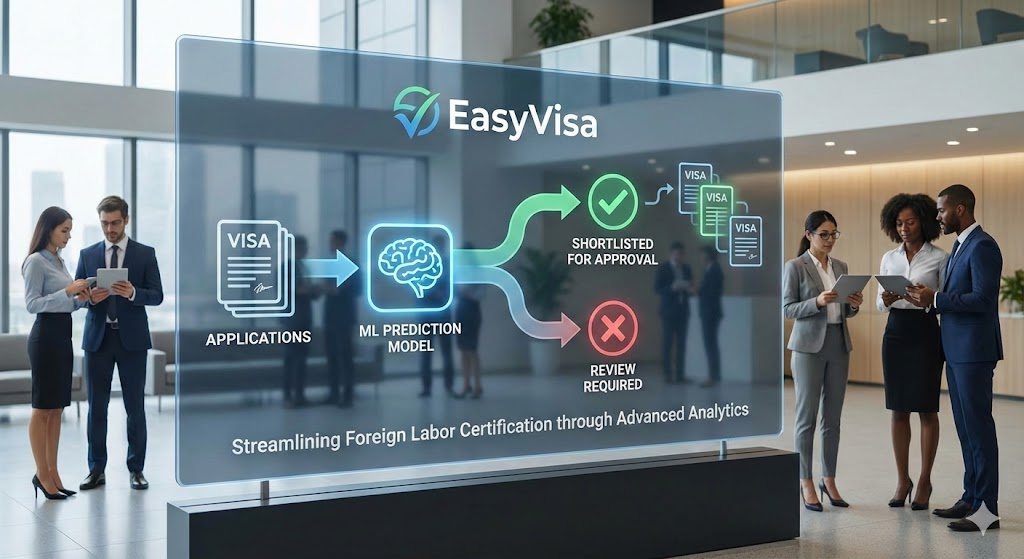

*\*\* Image generated by Gemini 3 Pro, an AI-powered tool*

### Context

U.S businesses face a constant challenge in finding and attracting the right talent, both locally and abroad. To address workforce shortages, the Immigration and Nationality Act (INA) allows employers to hire foreign workers on a temporary or permanent basis while safeguarding U.S workers wages and working conditions.

The Office of Foreign Labor Certification (OFLC) oversees these programs. It reviews employers applications to hire foreign workers and grants certification only when there are not enough qualified U.S workers available at the required wage level.

### Problem Statement

The Office of Foreign Labor Certification (OFLC) is experiencing a rapid increase in employer applications for labor certifications, making the manual review process increasingly time-consuming and inefficient.

With nearly 1.7 million positions processed in FY 2016 for 775,979 employer applications and application volumes rising each year, OFLC needs a scalable, data-driven approach to quickly identify applicants with a high likelihood of visa approval while maintaining compliance with U.S labor standards.

### Objective

As a data scientist at EasyVisa, the goal is to analyze the provided visa application dataset and develop a robust classification model that can:

* Predict visa approval outcomes to streamline the certification process.

* Identify key factors influencing visa approval or denial.

* Recommend suitable applicant profiles for certification or rejection based on data-driven insights.

* Ultimately, enhance efficiency in supporting OFLC's decision-making for labor certification cases.

### Data Dictionary

The data contains different attributes of the customers. Detailed description is mentioned below:


| Field | Detail |
| :------- | :------ |
| case_id | ID of each visa application |
| continent | Information of continent the employee |
| education_of_employee | Information of education of the employee |
| has_job_experience | Does the employee has any job experience? Y= Yes; N = No |
| requires_job_training | Does the employee require any job training? Y = Yes; N = No |
| no_of_employees | Number of employees in the employer's company |
| yr_of_estab | Year in which the employer's company was established |
| region_of_employment | Information of foreign worker's intended region of employment in the US |
| prevailing_wage | Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment |
| unit_of_wage | Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly |
| full_time_position | Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position |
| case_status | Flag indicating if the Visa was certified or denied |


Note:

From the data dictionary, it seems that case_status could be the target variable for this project

### Importing the necessary libraries

In [83]:
# Import warnings package to supress the warnings
import warnings
warnings.filterwarnings("ignore")

# Import all the necessary libraries
# Data Maniputation Libraries
import pandas as pd
import numpy as np

# Data visualization libraries
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit on displayed columns
pd.set_option("display.max_columns", None)

# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To be used for tuning the model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    make_scorer,
)

# Import Boosting algorithms
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To undersample and oversample the data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

### Load and View the Dataset

In [84]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
# Read the dataset from the drive path
df_main = pd.read_csv("/content/drive/MyDrive/PGP Course/Advanced Machine Learning/Project/EasyVisa.csv")

In [86]:
# Copy main data to avoid any changes to original dataset
data = df_main.copy()

### Overview of the dataset

#### View the first and last 5 rows of the dataset

In [87]:
data.head() #By default returns top 5 records

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20290,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65000,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86000,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03000,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39000,Year,Y,Certified


In [88]:
data.tail() #By default returns last 5 records

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57000,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79000,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85000,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77000,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91000,Year,Y,Certified


##### Observations

1. The dataset appears complete with all information provided
2. Based on the data dictionary and project objective, **case_status** appears to be the target variable (dependent variable) for this task. This column indicates the outcome of the visa application, with values '**Certified**' and '**Denied**'.
3. Has Job experience, Requires Job training and full time position seem to be holding Y or N, suggesting binary categorical variables.


### Understand the shape of the dataset

In [89]:
data.shape # Get the size and shape of dataset

(25480, 12)

**Observations:**

- The dataset has 25480 rows and 12 columns (features)

#### Check the data types of the columns for the dataset

In [90]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


**Observations:**
1. The dataset contains few numerical columns (2 integer, 1 float), and widely categorical columns(9)
2. The dataset doesn't have any NULL values
3. From the first and last 5 records, it is clear that Has Job experience, Requires Job training and full time position features hold Yes or No values, indicating binary categorical variables.
4. case_id column is probably an unique identifier.


#### Statistical summary of the data

**Let's check the statistical summary of the data.**

In [91]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.00000,5667.04321,22877.92885,-26.00000,1022.00000,2109.00000,3504.00000,602069.00000
yr_of_estab,25480.00000,1979.40993,42.36693,1800.00000,1976.00000,1997.00000,2005.00000,2016.00000
prevailing_wage,25480.00000,74455.81459,52815.94233,2.13670,34015.48000,70308.21000,107735.51250,319210.27000


##### Observations:

1. The minimum value for the number of employees is -26. Since the negative number of employees is not valid, seems like data entry error or noise that needs to be corrected
2. There is a huge disparity between the 75th percentile and the maximum value for no_of_employees. This suggest massive skewness in the employee count.
3. The companies range from historical (established in 1800) to relatively modern (2016).The median is 1997, indicating that half of the companies in this dataset were relatively older.
4. The Mean (\$74k) and Median (\$70k) are relatively close for **prevailing_wage**, but there's a jump from the 75th percentile (\$107k) to the Max (\$319k), suggesting few outliers.


### Data Preprocessing


#### Check for missing values

In [92]:
# checking for null values
data.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


NOTE: There are no NULL/missing values, which confirms our previous analysis based on info(), so no treatment needed.

#### Verify duplicate values

In [93]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

##### Observations:

There are no duplicates in the data set

#### Feature Engineering

1. Analyse unique Identifier column and drop as needed
2. Number of employees shows negative values which indicates data quality issues and needs to be treated

##### Dropping the columns with all unique values

In [94]:
data.case_id.nunique() #Find unique values

25480

In [95]:
# Drop the 'case_id' column as it is a unique identifier with no predictive power.

data = data.drop(["case_id"], axis=1)

##### Observations:

1. ID column has 25480 unique values (same as total rows)
2. This confirms case_id is a unique identifier with no duplicates
3. This column can be dropped safely as it doesn't provide predictive value for the model

##### Treat Negative Number of Employees values

Number of Employees feature has negative values, which is identified from the dataset statistics. Let's treat these negative values, since logically number of employees cannot be negative.

In [96]:
# Check negative employees rows count

(data['no_of_employees'] < 0).sum()

np.int64(33)

There are 33 records that have negative employees count.

In [97]:
# Correct negative values in no_of_employees with absolute values

data['no_of_employees'] = data['no_of_employees'].abs()

In [98]:
# Now let's check negative employees rows count
(data['no_of_employees'] < 0).sum()

np.int64(0)

**NOTE:**

- There are 0 negative values after treating them
- Negative employee count is invalid, and is converted into corresponding absolute values
- Corrected negative employee counts using absolute values to rectify likely sign-inversion errors.

### Exploratory Data Analysis (EDA)


#### Univariate Analysis

Numerical Variables:

* no_of_employees
* yr_of_estab
* prevailing_wage

Categorical variables:

* continent
* education_of_employee
* has_job_experience
* requires_job_training
* region_of_employment
* unit_of_wage
* full_time_position
* case_status


NOTE: has_job_experience, requires_job_training and full_time_position features hold either Y or N, and can be considered as categorical ordinal variables for our analysis.



Capture numeric and categorical columns for analysis

In [99]:
# Capture numeric and categorical columns for analysis
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
Categorical Columns: ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


There are 3 numerical columns and all others are categorical columns

Check unique values for categorical variables

In [100]:
# Check unique values for categorical columns
for col in categorical_cols:
    print(f"\n{col}: {data[col].nunique()} unique values")
    print(data[col].value_counts())


continent: 6 unique values
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

education_of_employee: 4 unique values
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

has_job_experience: 2 unique values
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64

requires_job_training: 2 unique values
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64

region_of_employment: 5 unique values
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64

unit_of_wage: 4 unique values
unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64

full_time_position: 2 unique values
full_time_position
Y    22773
N     2707
Name: count, dtype: int64

c

NOTE:

* continent has 6 unique values
* education_of_employee has 4 unique values
* has_job_experience has 2 unique values
* requires_job_training has 2 unique values
* region_of_employment has 5 unique values
* unit_of_wage has 4 unique values
* full_time_position has 2 unique values
* case_status has 2 unique values

##### Plot Histogram for Numeric Variables

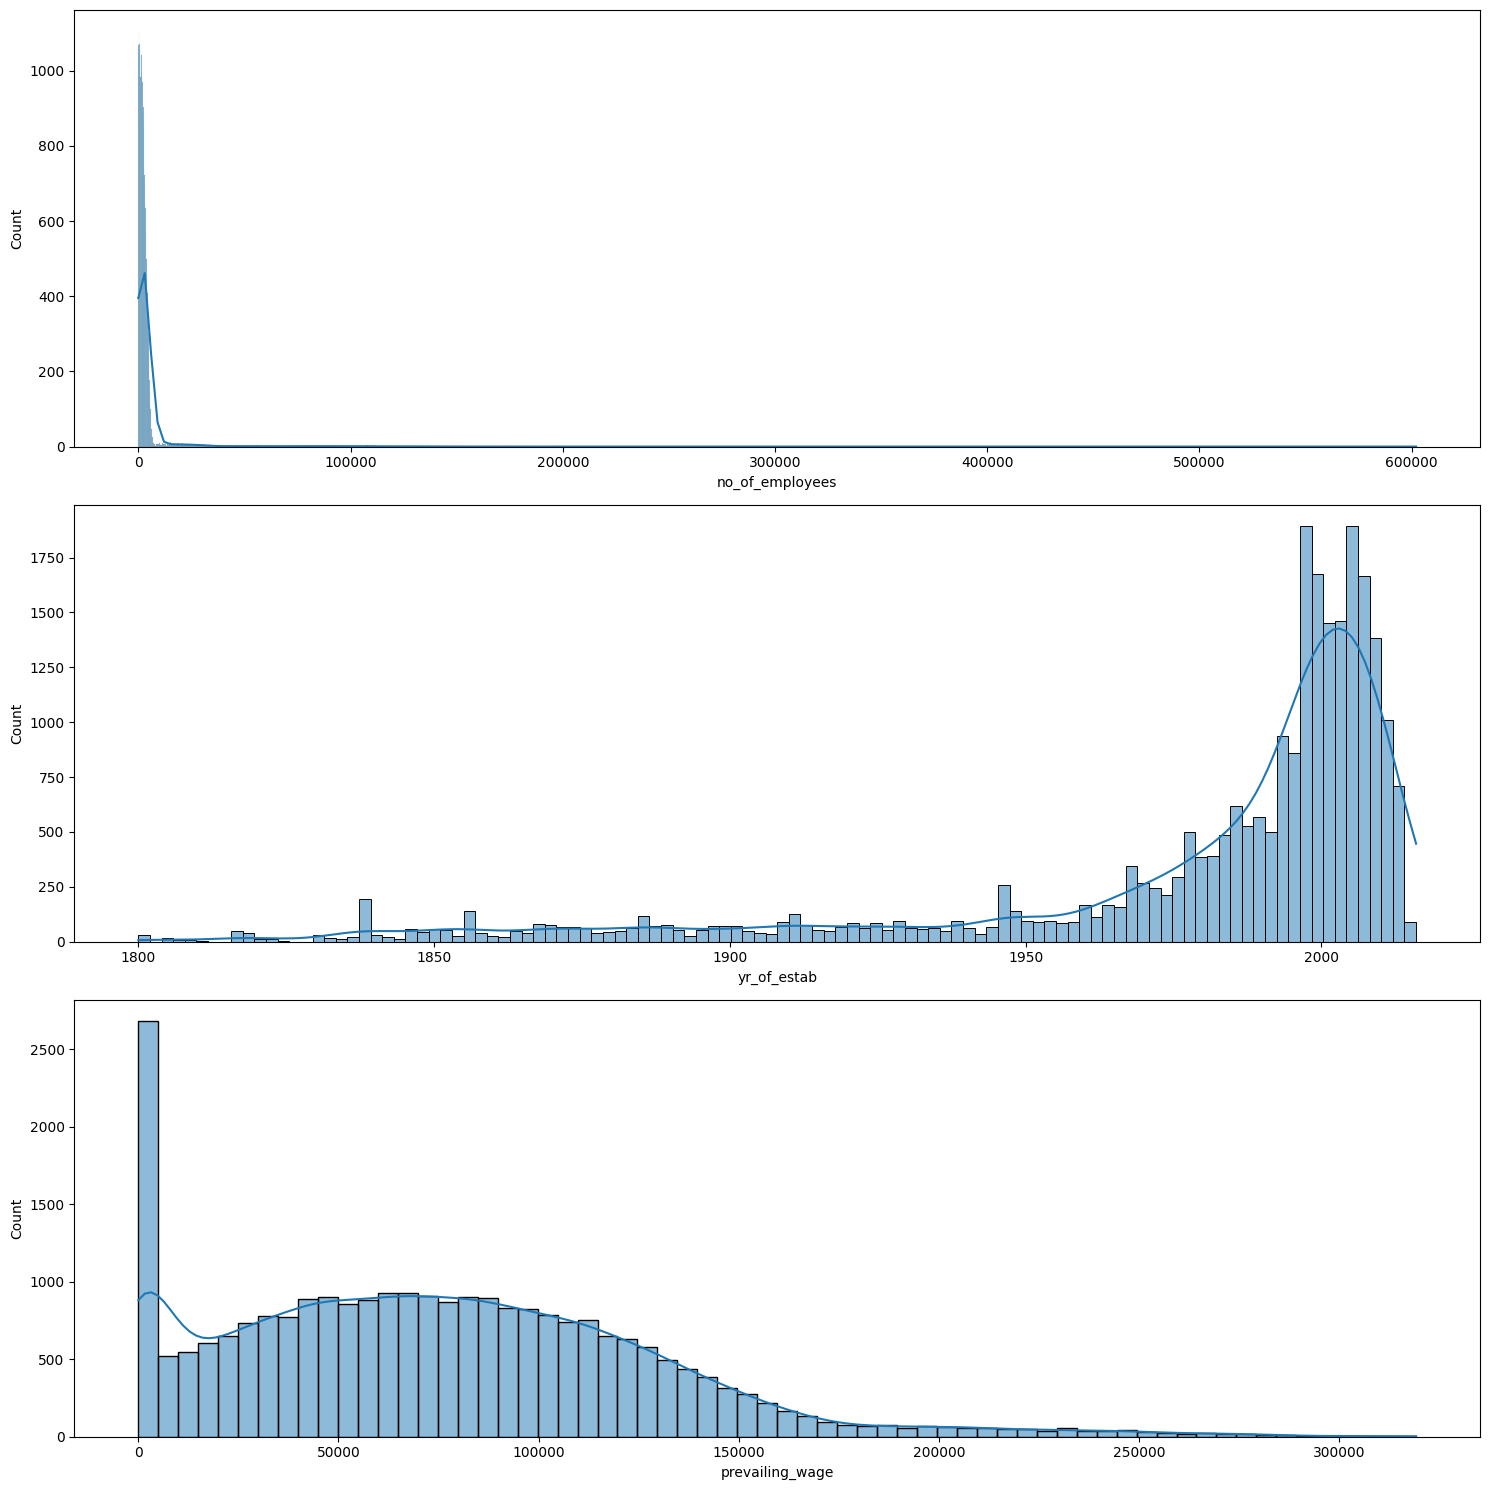

In [101]:
# Define the figure size
plt.figure(figsize=(15, 15))

# Plot the histogram for each numerical feature
for i, feature in enumerate(numerical_cols):
    plt.subplot(3, 1, i+1)    # assign a subplot in the main plot (3 per row)
    sns.histplot(data=data, x=feature, kde=True)    # plot the histogram

plt.tight_layout();   # Adds spacing between plots

**Observations from Histogram Plots:**

* no_of_employees
  - The distribution is heavily right-skewed (positively skewed).
  - The tall peak is concentrated almost entirely at the very beginning of the x-axis (near 0), with a long, flat tail extending to the right.
  - This confirms that the vast majority of companies have a small number of employees, while a few companies (outliers) with up to ~600K employees are stretching the scale.

* yr_of_estab
  - This distribution is left-skewed (negatively skewed), showing an increasing trend over time.
  - The frequency of companies increases as the years progress, with the highest concentration of companies being established between 1990 and 2016.
  - There is a long tail stretching back to the 1800s, representing the few very old companies in the dataset.

* prevailing_wage
  - The distribution is generally right-skewed
  - There is a distinct, sharp spike at the very far left (near 0).
  - The rest of the data forms a bell-like curve centered roughly between \$50K and \$100K



##### Plot Boxplot for Numeric features

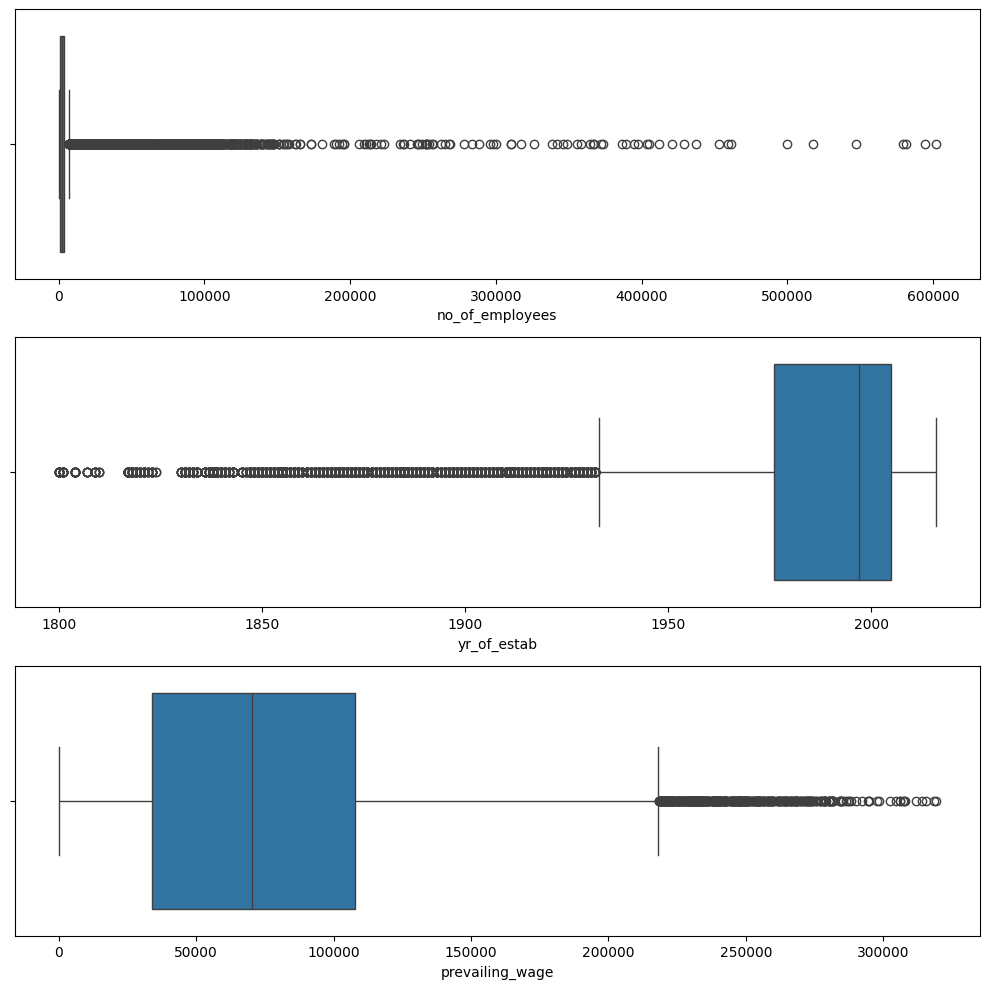

In [102]:
# Define the figure size
plt.figure(figsize=(10, 10))

# Plot the histogram for each numerical feature
for i, feature in enumerate(numerical_cols):
    plt.subplot(3, 1, i+1)    # assign a subplot in the main plot (1 per row)
    sns.boxplot(data=data, x=feature) # plot the boxplot

plt.tight_layout();   # Adds spacing between plots

**Observations from Histogram Plots:**


- no_of_employees
  - The box (representing the middle 50% of data) is completely squashed against the left axis (near 0).
  - There are many outliers extending all the way to 600K

- yr_of_estab
  - The box is pushed to the right, indicating that most companies were established recently
  - Median (50%) is around ~1997
  - There is a long tail of outliers on the left side, stretching back to 1800.

- prevailing_wage
  - The box is more spread out compared to the employee count, with the middle 50% (Interquartile Range) falling roughly between 34k and 107k
  - There are significant outliers on the right side, with wages extending up to nearly 320k.



##### Count plot for binary categorical variables

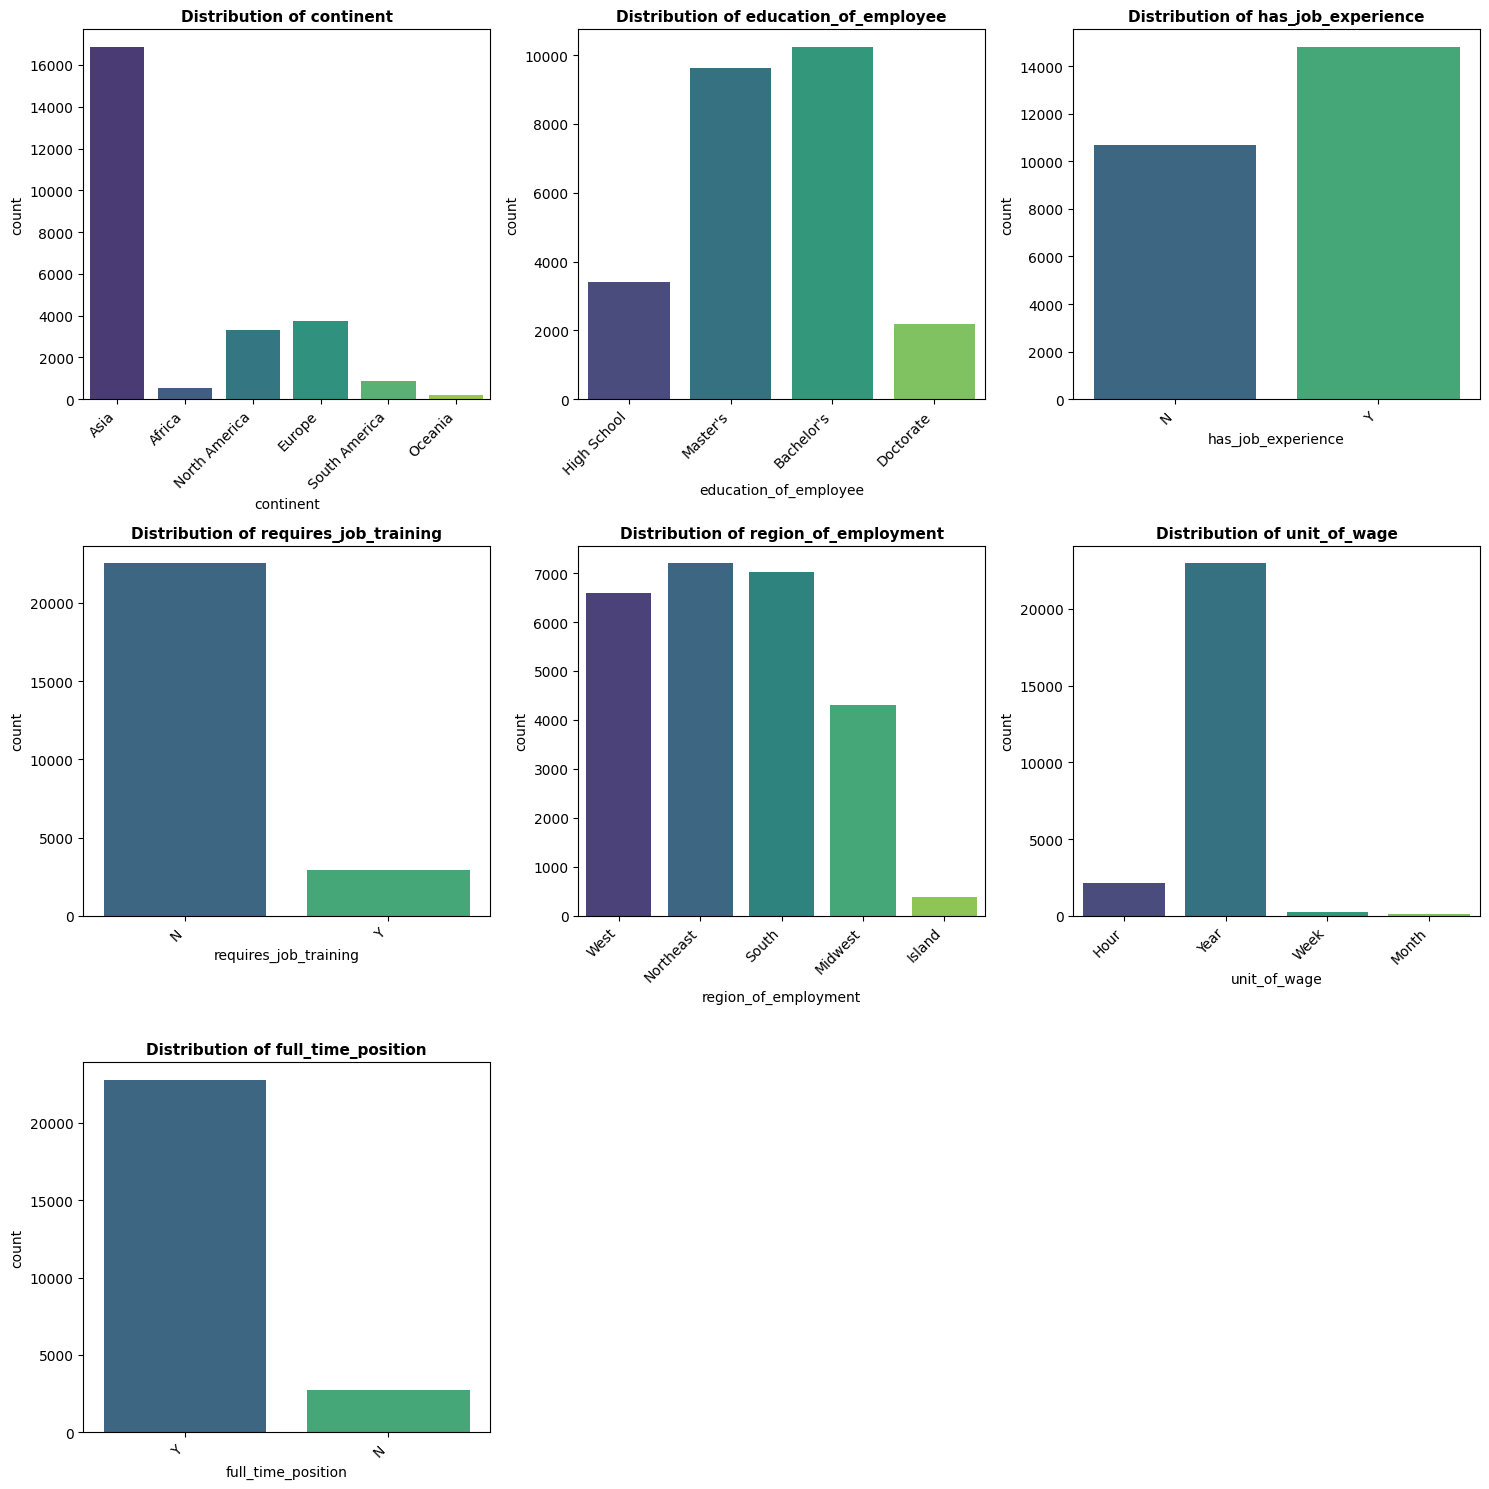

In [103]:
# checking the distribution of the categories

# Get current object-type categorical columns and exclude 'case_status'
plot_categorical_cols = data.select_dtypes(include='object').columns.tolist()
if 'case_status' in plot_categorical_cols:
    plot_categorical_cols.remove('case_status')


plt.figure(figsize=(15, 15)) # Adjust figure size

for i, feature in enumerate(plot_categorical_cols):
    plt.subplot(3, 3, i+1) # assign a subplot in the main plot (3 per row)
    sns.countplot(data=data, x=feature, palette='viridis')    # plot the count plot
    plt.title(f'Distribution of {feature}', fontsize=11, fontweight='bold')
    plt.xlabel(feature)
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels

plt.tight_layout();    # to add spacing between plots
plt.show()

**Observations:**

* **continent**
  - The data is heavily skewed toward Asia, which accounts for the vast majority of applicants (over 16,000).
  - Other continents like Europe, North America, and South America have significantly lower representation, all below 4,000 counts.

* **education_of_employee**
  - Most applicants are highly educated. The distribution is dominated by Master's and Bachelor's degrees, both hovering around 10,000 count
  - High School and Doctorate degrees are less common (less than 4000).

* **Job** **Experience** (has_job_experience)

  - It has a good balanced split, but a preference for experience.
  - Applicants with prior experience (Y) outnumber those without (N) by a margin of roughly 14,000 to 10,000.

* **Job Training** (requires_job_training)

  - The majority of positions do not require job training (N > 20,000), which is a great thing for employers

* **Full Time Status** (full_time_position)
  - Nearly all positions are full-Time (Y) (>20000), with very few part-time or contract roles.

* **Region of Employment** (region_of_employment)
  - Employment is distributed relatively evenly across the Northeast, South, and West (all between 6K-7K count)
  - The Midwest lags behind (~4K), and Island territories are negligible.

* **Unit of Wage** (unit_of_wage)
  - The vast majority (>20000) of wages are reported by Year (Annual Salary)
  - Month and Weekly wage counts are negligible (around 100-200)


**Key Insights:**

* The plots suggests the dataset pertains to skilled labor or specialized professional roles
* Companies expect applicants to be job-ready upon hiring, reinforcing the high education observation.


#### Multi Variate Analysis

Let's try to understand the relation between numerical variables, and also between numerical and categorical variables which we have identified earlier.



##### Correlation Map

1. Plot correlation map for all the numeric variables.
2. This helps in understanding the correlation between them.

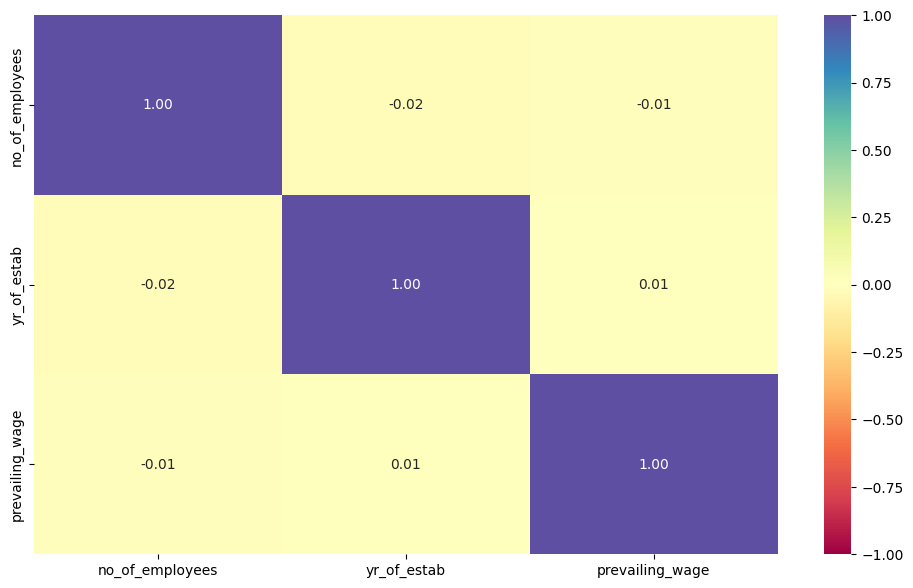

In [104]:
# defining the size of the plot
plt.figure(figsize=(12, 7))

# plotting the heatmap for correlation
sns.heatmap(
    data[numerical_cols].corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
);

**Observations:**

* Zero Linear Correlation
  - The most striking finding is that there is virtually no linear relationship between any of these three variables.
  - All correlation coefficients are extremely close to zero.

* The size of the company does not dictate the wages they offer. Massive corporations do not necessarily pay more or less than small businesses for these specific roles.

* The age of the company has no bearing on the salary offered. Established legacy companies pay the same prevailing wages as newer entrants.

##### Target vs Numerical Values

###### Pair Plot

Let's try to understand the relation between numerical variables against our target case_status

<Figure size 1200x800 with 0 Axes>

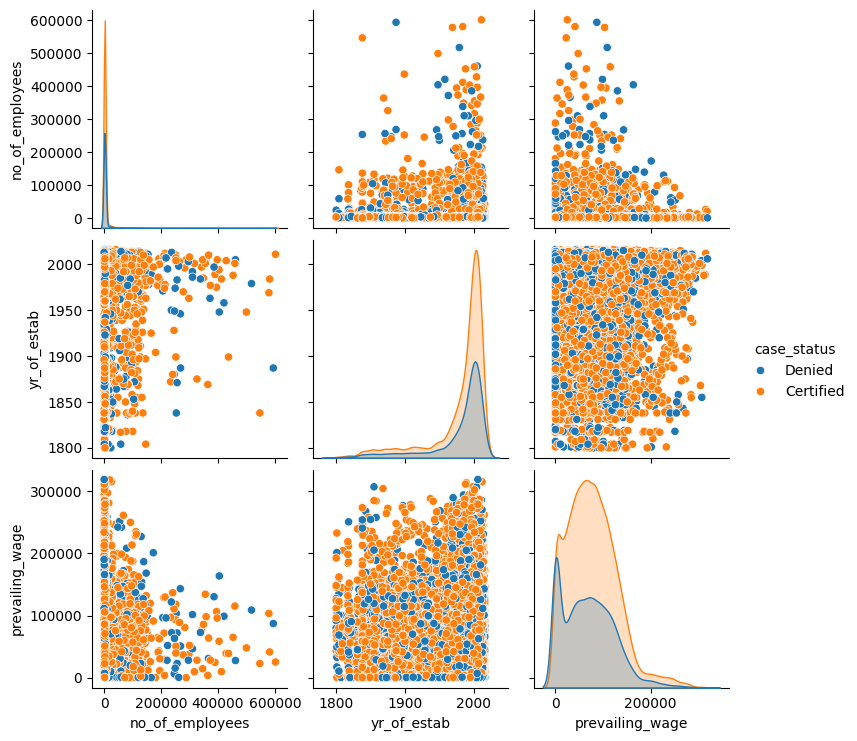

In [105]:
# Scatter Pair plot matrix
plt.figure(figsize=(12, 8))
sns.pairplot(data, vars=numerical_cols, hue='case_status', diag_kind='kde')
plt.show();

**Observations:**

1. The scatter plot clearly shows no proper correlation among the numerical columns
2. The numerical features provide independent information
3. A company's age doesn't predict its size, and its size doesn't predict the wages it pays.

##### Box Plot - Numerical features vs Target

**Let's try to understand relation between target variable and other numerical variables**

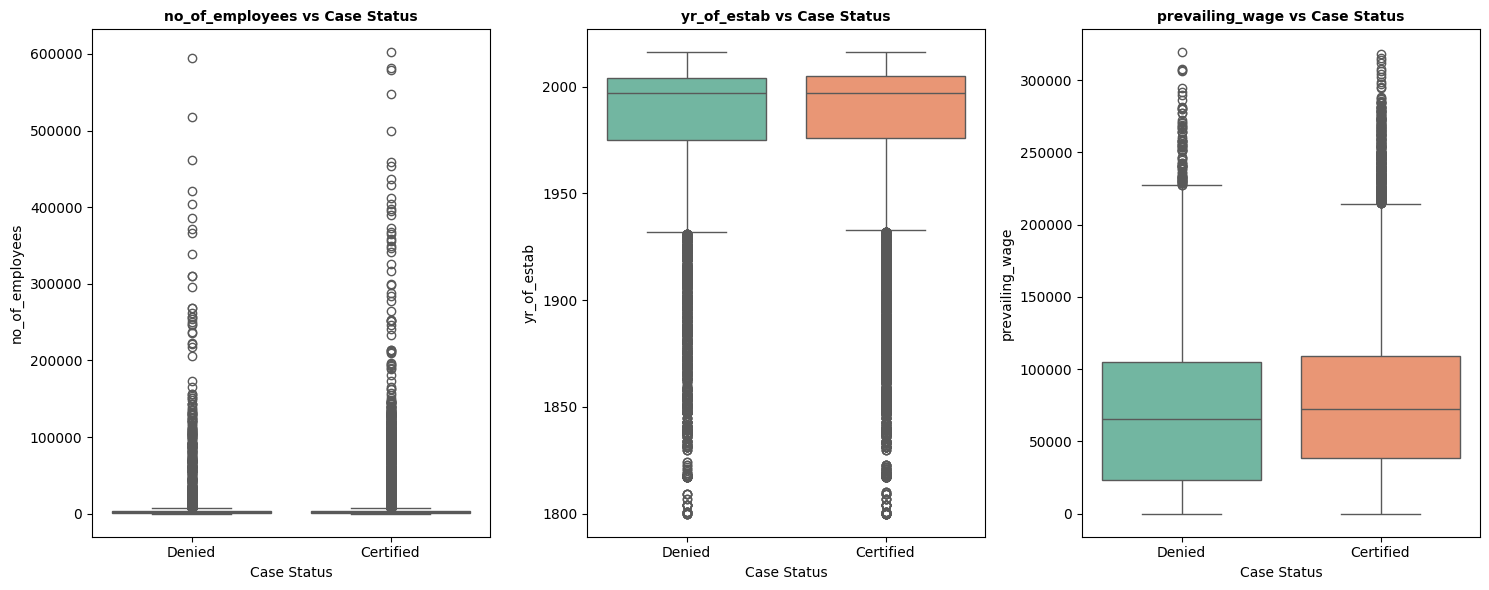

In [106]:
# Numerical features vs Target

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    sns.boxplot(data=data, x='case_status', y=col, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{col} vs Case Status', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Case Status')

plt.tight_layout()
plt.show()

**Observations:**

The boxplots validate the heatmap findings by visualizing the distribution of key features against the target variable

- The median prevailing wage for Certified cases (orange) is noticeably higher (~70K) than for Denied cases (green).

- The box plots for yr_of_estab are almost identical for both **Denied** and **Certified** cases. Their medians are roughly at the year 2000, and their spreads are similar.

- Higher wages correlate with a higher chance of approval.

- The age of a company might not a strong predictor of visa approval.

- Both Denied and Certified categories show heavy right skew for the companies. Majority of companies have relatively small employee counts. A few companies have very large employee counts (100k-600k+)

##### Categorical features vs Target(case_status)

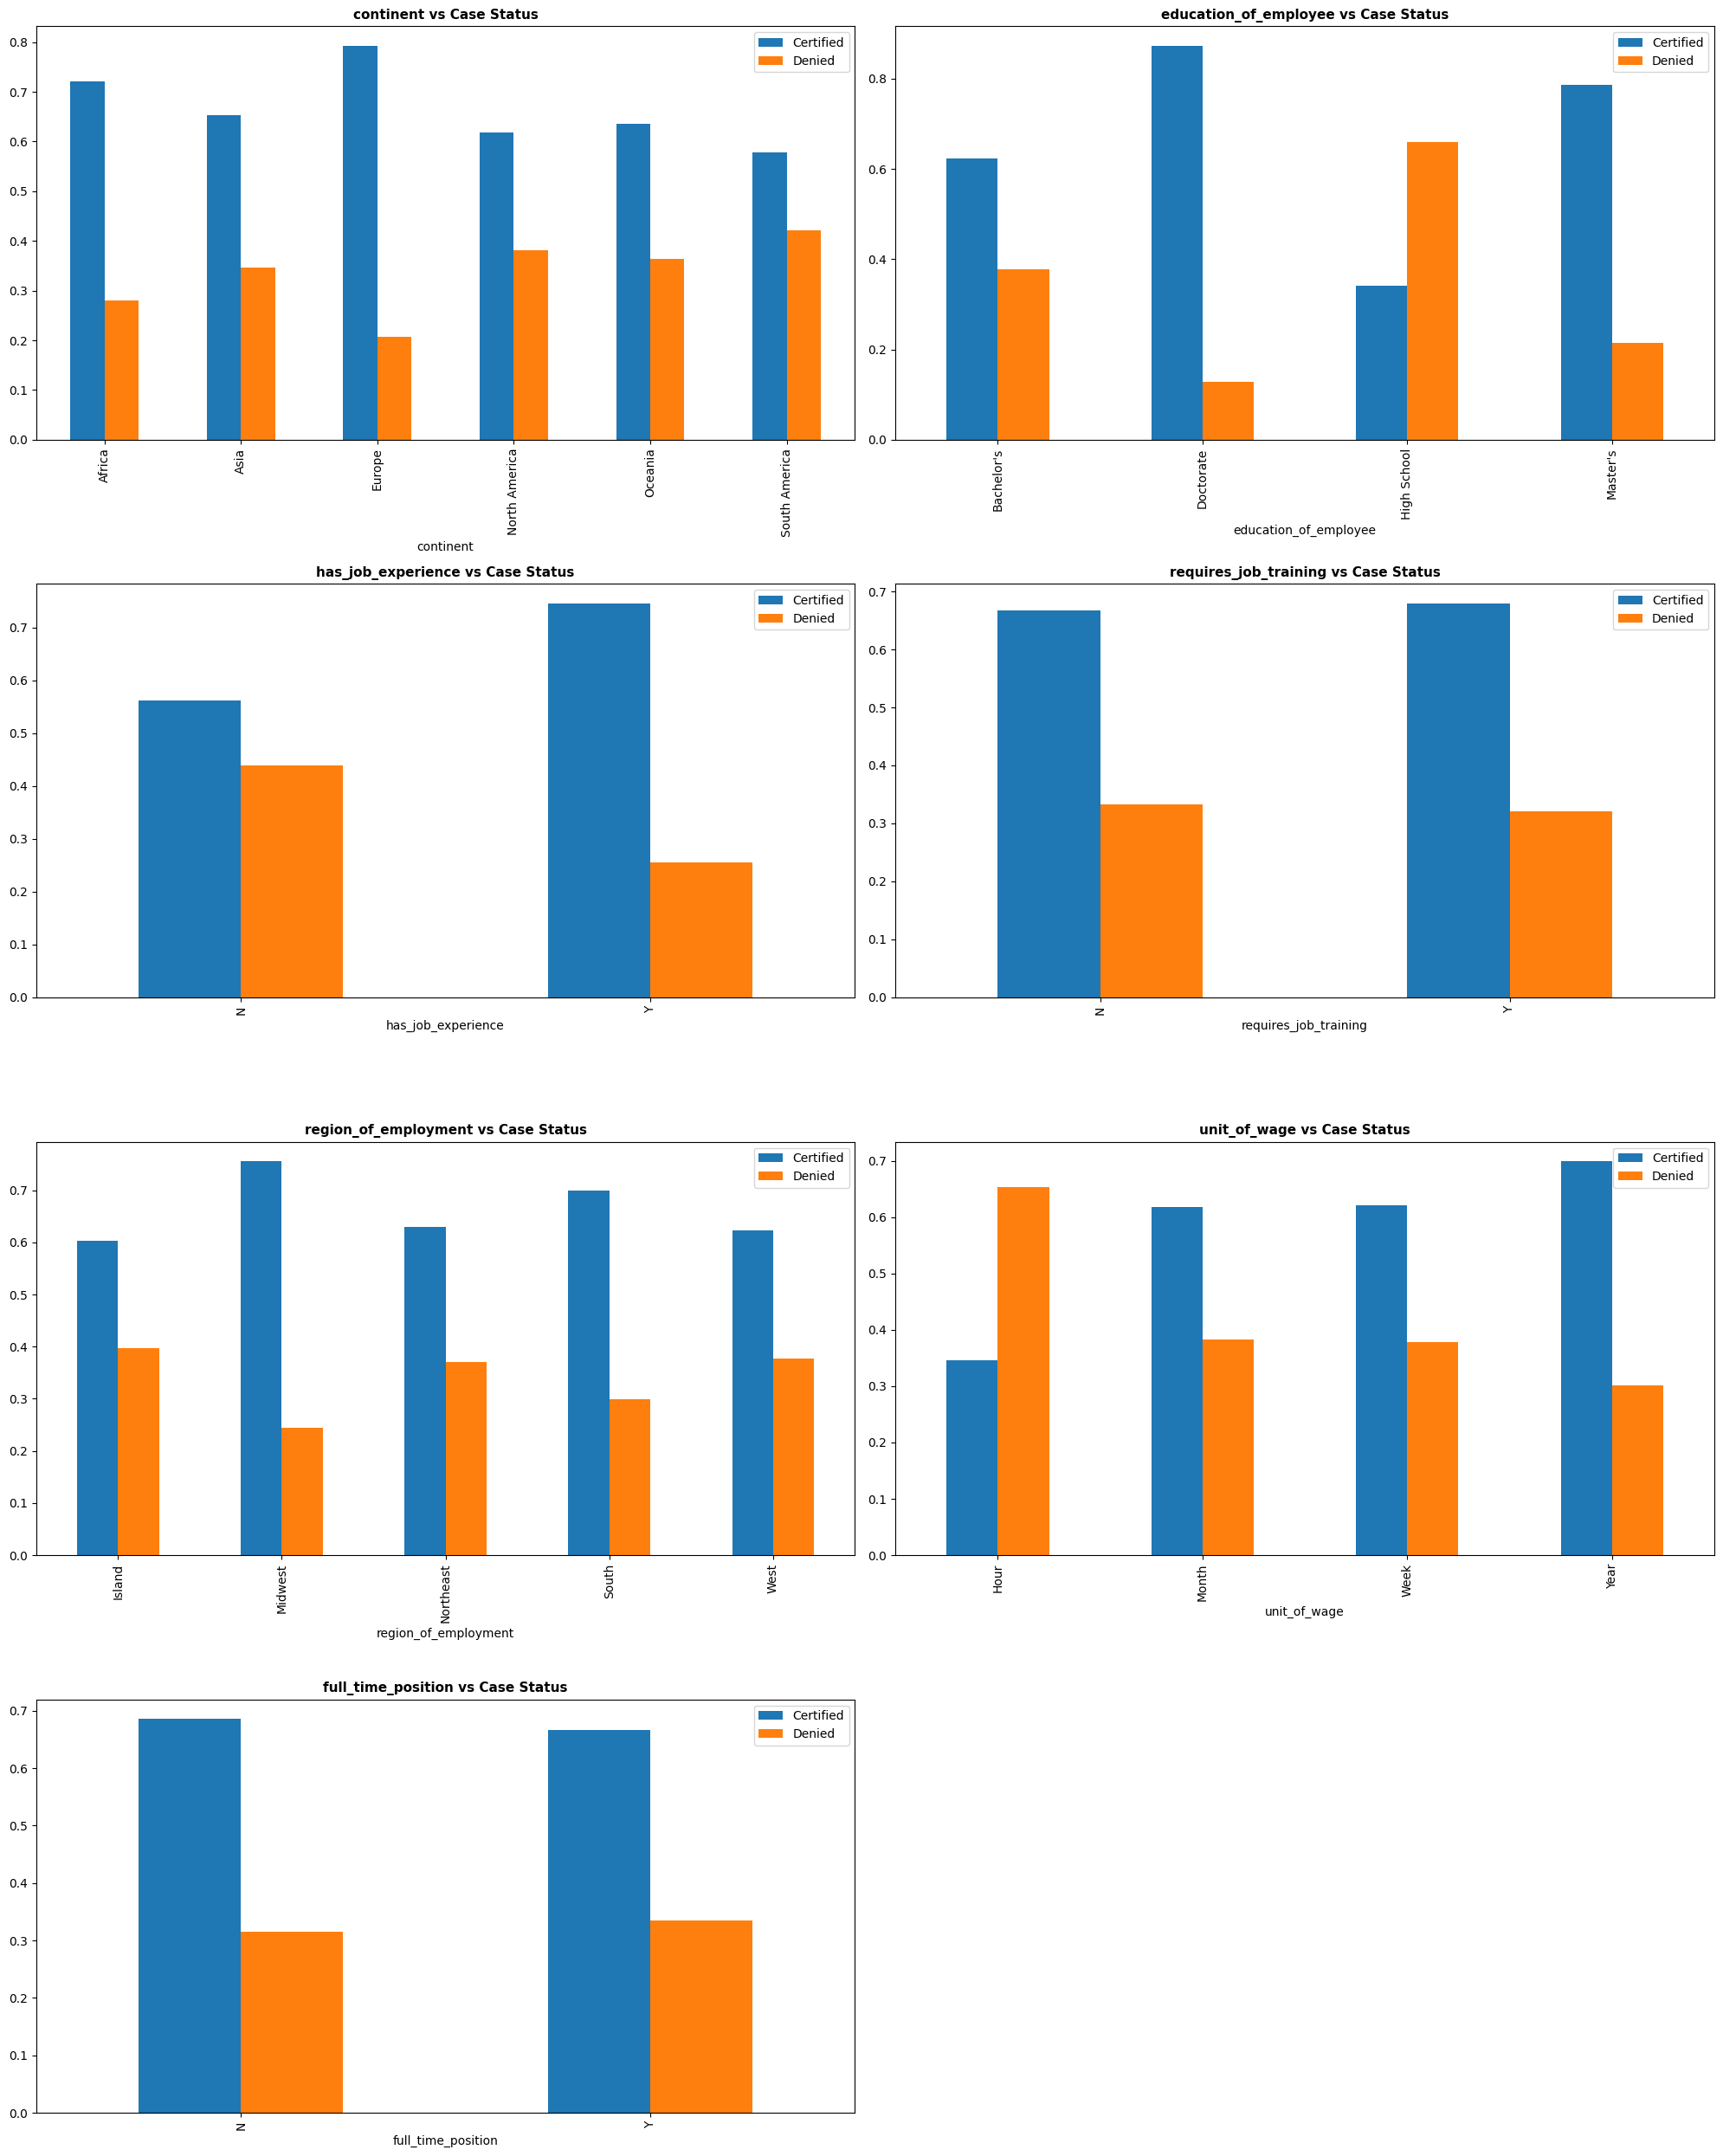

In [107]:
# Categorical features vs Target
fig, axes = plt.subplots(4, 2, figsize=(20, 25))
axes = axes.ravel()

for idx, col in enumerate(plot_categorical_cols):
    pd.crosstab(data[col], data['case_status'], normalize='index').plot(
        kind='bar', ax=axes[idx], stacked=False)
    axes[idx].set_title(f'{col} vs Case Status', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].legend(['Certified', 'Denied'])
    axes[idx].tick_params(axis='x', rotation=90)


# Remove the empty axes (from index 7 to the end)
for ax in axes[7:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

**Observations:**

Education:

- High School is the only education category where the Denied (orange) bar is significantly taller than the Certified (blue) bar.

- This indicates that applicants with only a High School education are more likely to be rejected than approved.

- Doctorate holders have the highest likelihood of certification, with a negligible denial rate.

Continent and Region:

- Europe has highest rate of approvals, while South America has highest rate of Denials
- The Midwest region appears to have the most favorable ratio of approvals to denials compared to other regions like the West or South.

Experience:

- Applicants with prior job experience (Y) have a much higher certification rate compared to those without (N).

Wage:

- Applicants with an 'Hour' unit of wage have a much higher Denied rate than Certified rate.

- In contrast, applicants paid by "Year" (salaried) show a massive preference for "Certified" status.

** *requires_job_training and full_time_position have the patterns that doesn't change significantly between the two groups*

### Data Preprocessing (Contd)

#### Outlier Detection

**Let's check for outliers in the data.**

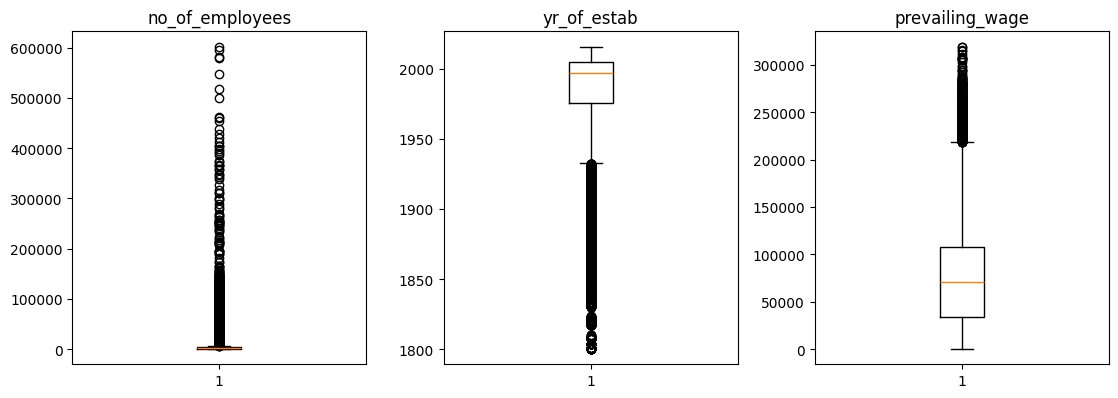

In [108]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 15))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

Observations

- Significant outliers and skewness are present across all numeric variables (e.g., prevailing wage and number of employees).
- These were determined to be legitimate data points rather than errors. Consequently, these outliers were not removed or capped.
- This data characteristic justifies the selection of tree-based ensemble models (like Random Forest and XGBoost), which are inherently robust to outliers and non-normal distributions.

### Data Preparation for Modeling

- The analysis confirms that **case_status** is the target variable for this classification problem.
- Correlation between numerical variables is negligible (near 0), indicating that multicollinearity is not a concern.
- Binary categorical features (has_job_experience, requires_job_training, full_time_position) currently encoded as Y/N will be mapped to binary integers (1/0)
- The target variable case_status contains two unique classes ('Certified' and 'Denied'). We will apply Label Encoding to convert these into a numerical format (e.g., Certified=1, Denied=0).
- For nominal categorical features, we will use One-Hot Encoding.
- Encoding will be performed after the train-test split. We will fit the encoders on the training set only and then transform the validation/test sets. This standard practice prevents **data leakage** by ensuring the model is not exposed to information from the test set during training.

##### Encode Target variable

In [109]:
# Target mapping (before split - no leakage)

data['case_status'] = data['case_status'].map({'Certified': 1, 'Denied': 0})

data['case_status']

,case_status
0,0
1,1
2,0
3,0
4,1
...,...
25475,1
25476,1
25477,1
25478,1


* Case Status containing Y is mapped to 1, and N is mapped to 0
* This field now contains 1 (or) 0 in the dataset after encoding

##### Encode Binary categorical variables

In [110]:
# Binary mapping (before split - no leakage)

binary_map = {'Y': 1, 'N': 0}

for col in ['has_job_experience', 'requires_job_training', 'full_time_position']:
    data[col] = data[col].map(binary_map)

* Dataset now contains 0/1 instead of N/Y for these 3 variables

##### Split the data

In [111]:
# Assign target variable to 'y'
y = data['case_status']

# case_status is a target variable, hence dropped from input features
X = data.drop('case_status', axis=1)

In [112]:
# First split: 70% train, 30% temp (which will be split into val and test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

# Second split: Split temp into 50% validation, 50% test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=1, stratify=y_temp
)


# Helper function to format the string
def format_distribution(y_data):
    counts = pd.Series(y_data).value_counts().sort_index()
    percents = pd.Series(y_data).value_counts(normalize=True).sort_index() * 100

    return ", ".join([f"{cls}: {count} ({percents[cls]:.1f}%)" for cls, count in counts.items()])


print("Data Split Summary:")
print(f"{'='*50}")
print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(y)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(y)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(y)*100:.1f}%)")

print(f"\nClass distribution:")
print(f"Training:   {format_distribution(y_train)}")
print(f"Validation: {format_distribution(y_val)}")
print(f"Test:       {format_distribution(y_test)}")

Data Split Summary:
Training set:   17836 samples (70.0%)
Validation set: 3822 samples (15.0%)
Test set:       3822 samples (15.0%)

Class distribution:
Training:   0: 5923 (33.2%), 1: 11913 (66.8%)
Validation: 0: 1270 (33.2%), 1: 2552 (66.8%)
Test:       0: 1269 (33.2%), 1: 2553 (66.8%)


Observations:

1. It can be observed that the proportion is divided perfectly for training (70%), validation set (15%) and test set (15%)

2. The target variable case_status shows imbalance, with 66.8% **Certified** (Majority) and 33.2% **Denied** (Minority)

3. Given the imbalance and the cost of errors, we will prioritize the F1-Score over Accuracy

    - **False Positives:** Approving an ineligible candidate might create compliance/legal risks.

    - **False Negatives:** Denying an eligible candidate causes talent loss for the employer.
    
    - Since both errors have significant negative impacts, maximizing the F1-Score ensures we balance the trade-off

4. Balancing the class proportion while predicting the model also plays a crucial role

##### One Hot Encoding

In [113]:
# Perform One Hot encoding on train, validation and test data sets (Avoids data leakage)

X_train = pd.get_dummies(X_train, drop_first=True)
X_train = X_train.astype(float)

X_val = pd.get_dummies(X_val, drop_first=True)
X_val = X_val.astype(float)

X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.astype(float)

# Display the current dataset shape after encoding
print(X_train.shape, X_val.shape, X_test.shape)

(17836, 21) (3822, 21) (3822, 21)


**Observations:**

1. After encoding, we can now see the features are increased to 21
2. One-Hot Encoding was applied consistently across all three datasets (Train, Validation, and Test)
3. As expected, the feature space has expanded (from the original count to 21 features). This increase is due to the creation of separate binary columns for each unique category
4. By performing the split before encoding, we ensured that the model was not exposed to any information from the validation or test sets during the preprocessing phase. This strictly follows the best practices for preventing data leakage.


## Model Building

**Model can make wrong predictions as:**

1. Predicting that Visa can be approved/certified for an ineligible candidate - legal/compliance risks (False Positives)
2. Predicting that Visa can be denied for an eligible candidate - Talent loss (False Negatives)

Since both errors have significant negative impacts, maximizing the F1-Score ensures we balance the trade-offs.

**Let's define reusable function to output different metrics on the training, validation and test set**

In [114]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

 **Function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [115]:
def confusion_matrix_sklearn(model, predictors, target, ax=None):
    """
    To plot the confusion_matrix with percentages on a specific axis.

    model: classifier
    predictors: independent variables
    target: dependent variable
    ax: matplotlib axes object (optional)
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)

    # Create the labels with counts and percentages
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    # If no axis is passed, create a new figure (for standalone use)
    if ax is None:
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=labels, fmt="")
        plt.ylabel("True label")
        plt.xlabel("Predicted label")
        plt.show()
    else:
        # Plot on the passed axis
        sns.heatmap(cm, annot=labels, fmt="",  ax=ax, cbar=False)
        ax.set_ylabel("True label")
        ax.set_xlabel("Predicted label")

## Initial Model Building

For this EasyVisa project, we proceed with the various models and compare a simple baseline (Decision Tree) against powerful ensemble methods, using Bagging to stabilize predictions and Boosting to improve performance on difficult cases, ensuring we end up with the most performant model for building a reliable visa approval system.

### Model Building - Original Data



Let's build this classification problem with below models on the original data:

1. Decision Tree
2. Random Forest
3. Bagging
4. Ada Boost
5. Gradient Boost
6. XGBoost

In [116]:
#Define all the models and capture performance of the models on training data

models = []  # Empty list to store all the models

#Appending models into the list
#Decision Tree Classifier
models.append(("Decision Tree",
               DecisionTreeClassifier(random_state=1, class_weight='balanced'))) #Evaluate with balanced class weight

#Random Forest Classifier
models.append(("Random forest",
               RandomForestClassifier(random_state=1, class_weight='balanced'))) #Evaluate with balanced class weight

#Bagging Classifier with Decision Tree
models.append(("Bagging",
               BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
#Evaluate with balanced class weight

#GradientBoost Classifier
models.append(("GradientBoost",
               GradientBoostingClassifier(random_state=1)))

#AdaBoost Classifier
models.append(("Adaboost",
               AdaBoostClassifier(random_state=1)))

#XGBoost Classifier
models.append(("XGBoost",
               XGBClassifier(random_state=1,eval_metric='logloss'))) #Ignore warnings with logloss



In [117]:
# Plot training performance and validation performance of all the models

train_scores = [] #Empty list to store training scores
val_scores = [] #Empty list to store validation scores

# Loop through models
for name, model in models:
    # Fit the model
    model.fit(X_train, y_train)

    # Training performance
    train_score = model_performance_classification_sklearn(model, X_train, y_train)
    # Set the index to the model name (currently it might be 0 or empty)
    train_score.index = [name]
    train_scores.append(train_score)

    # Validation performance
    val_score = model_performance_classification_sklearn(model, X_val, y_val)
    # Set the index to the model name
    val_score.index = [name]
    val_scores.append(val_score)

# Concatenate all rows (Result: Models as Index, Metrics as Columns)
train_perf_df = pd.concat(train_scores)
val_perf_df = pd.concat(val_scores)

# Transpose the DataFrames (Result: Metrics as Index, Models as Columns)
train_perf_final = train_perf_df.T
val_perf_final = val_perf_df.T

# Display
print("Training Performance:")
display(train_perf_final)

print("\nValidation Performance:")
display(val_perf_final)

Training Performance:


,Decision Tree,Random forest,Bagging,GradientBoost,Adaboost,XGBoost
Accuracy,1.00000,0.99994,0.98542,0.75880,0.73968,0.84144
Recall,1.00000,0.99992,0.98674,0.88374,0.88735,0.92982
Precision,1.00000,1.00000,0.99140,0.78304,0.76204,0.84758
F1,1.00000,0.99996,0.98906,0.83035,0.81993,0.88680



Validation Performance:


,Decision Tree,Random forest,Bagging,GradientBoost,Adaboost,XGBoost
Accuracy,0.65777,0.72658,0.69806,0.74516,0.73522,0.72920
Recall,0.75745,0.84404,0.78017,0.88166,0.88871,0.85031
Precision,0.73722,0.76901,0.77051,0.77002,0.75701,0.76869
F1,0.74720,0.80478,0.77531,0.82207,0.81759,0.80744


Observations:

* Massive Overfitting in Tree-Based Models
  - The Decision Tree, Random Forest, and Bagging Classifier are exhibiting severe overfitting.
  - **Decision Tree**
    - Achieved a perfect 1.0 (100%) on training data but dropped drastically to ~0.74 (74%) F1 score in Validation.
    - This suggests the tree memorized the training noise and failed to learn general patterns.
  - **Random Forest**
    - It has near-perfect training scores (~0.999) but drops to ~0.80 F1 score in Validation.
  - **Bagging**
    - It has near-perfect training scores (~0.98) but drops to ~0.77 F1 score in Validation.


 These models are currently too complex and overfitting. They need hyperparameter tuning to improve generalization.

* Boosting Models

  - Gradient Boosting and AdaBoost are performing much more reliably. XGBoost shows highest performance on training data
  - Gradient Boosting
    - The gap between Training F1 (0.83) and Validation F1 (0.82) is very small. This indicates a stable, robust model
  - AdaBoost
    - The gap between Training F1 (0.819) and Validation F1 (0.817) is very small.
  - XGBoost Performance
    - It has higher Training F1 (0.886) compared to other boosting methods, indicating it captured more complexity.
    - However, it sees a noticeable drop in validation F1 (0.807), suggesting it is slightly overfitting compared to Gradient Boosting/AdaBoost, but far less than Random Forest.


Plot the confusion matrix on training data

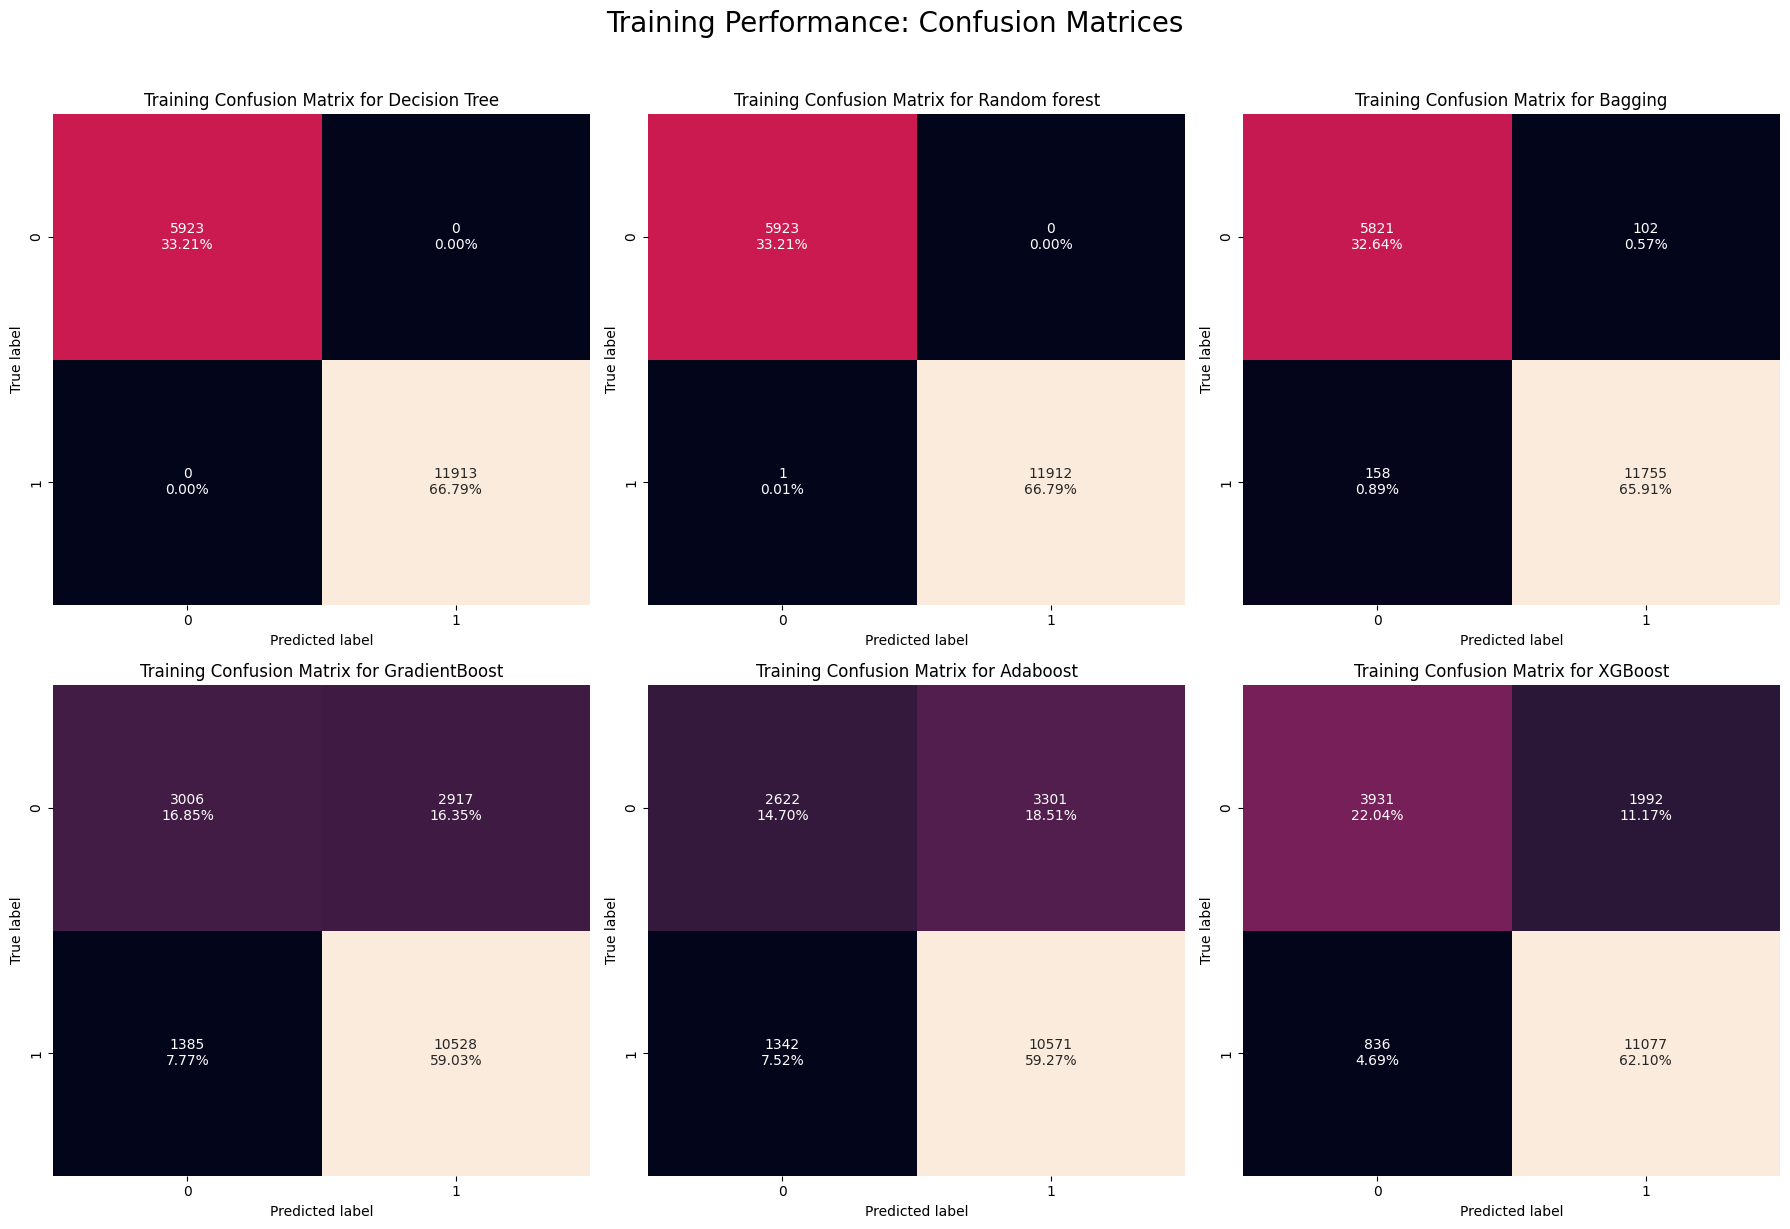

In [118]:
# Create the Grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.suptitle('Training Performance: Confusion Matrices', fontsize=20, y=1.02)
axes = axes.flatten()

# Loop through models
for i, (name, model) in enumerate(models):
    # Fit the model
    model.fit(X_train, y_train)
    #Plot the confusion matrix
    confusion_matrix_sklearn(model, X_train, y_train, ax=axes[i])

    # Set the title on the axis object directly
    axes[i].set_title(f"Training Confusion Matrix for {name}")

# Handle extra empty plots (if any)
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observations:

* The confusion matrix clearly shows the validations from metrics captured above for training data

* Decision Tree
  - Perfectly overfits the training data (0% for FP and FN)
* Random Forest
  - Same as decision tree. Overfits the training data
* Bagging
  - Nearly overfitting the data. False Positives are around 0.57%, False Negatives are around 0.89%
* Gradient Boost
  - Confusion matrix shows around 16.3% False Positives, 7.7% False negatives
* Ada Boost
  - Confusion matrix shows around 18.5% False Positives, 7.5% False negatives
* XGBoost
  - Confusion matrix shows around 11.1% False Positives, 4.6% False negatives

Plot the confusion matrix on validation data

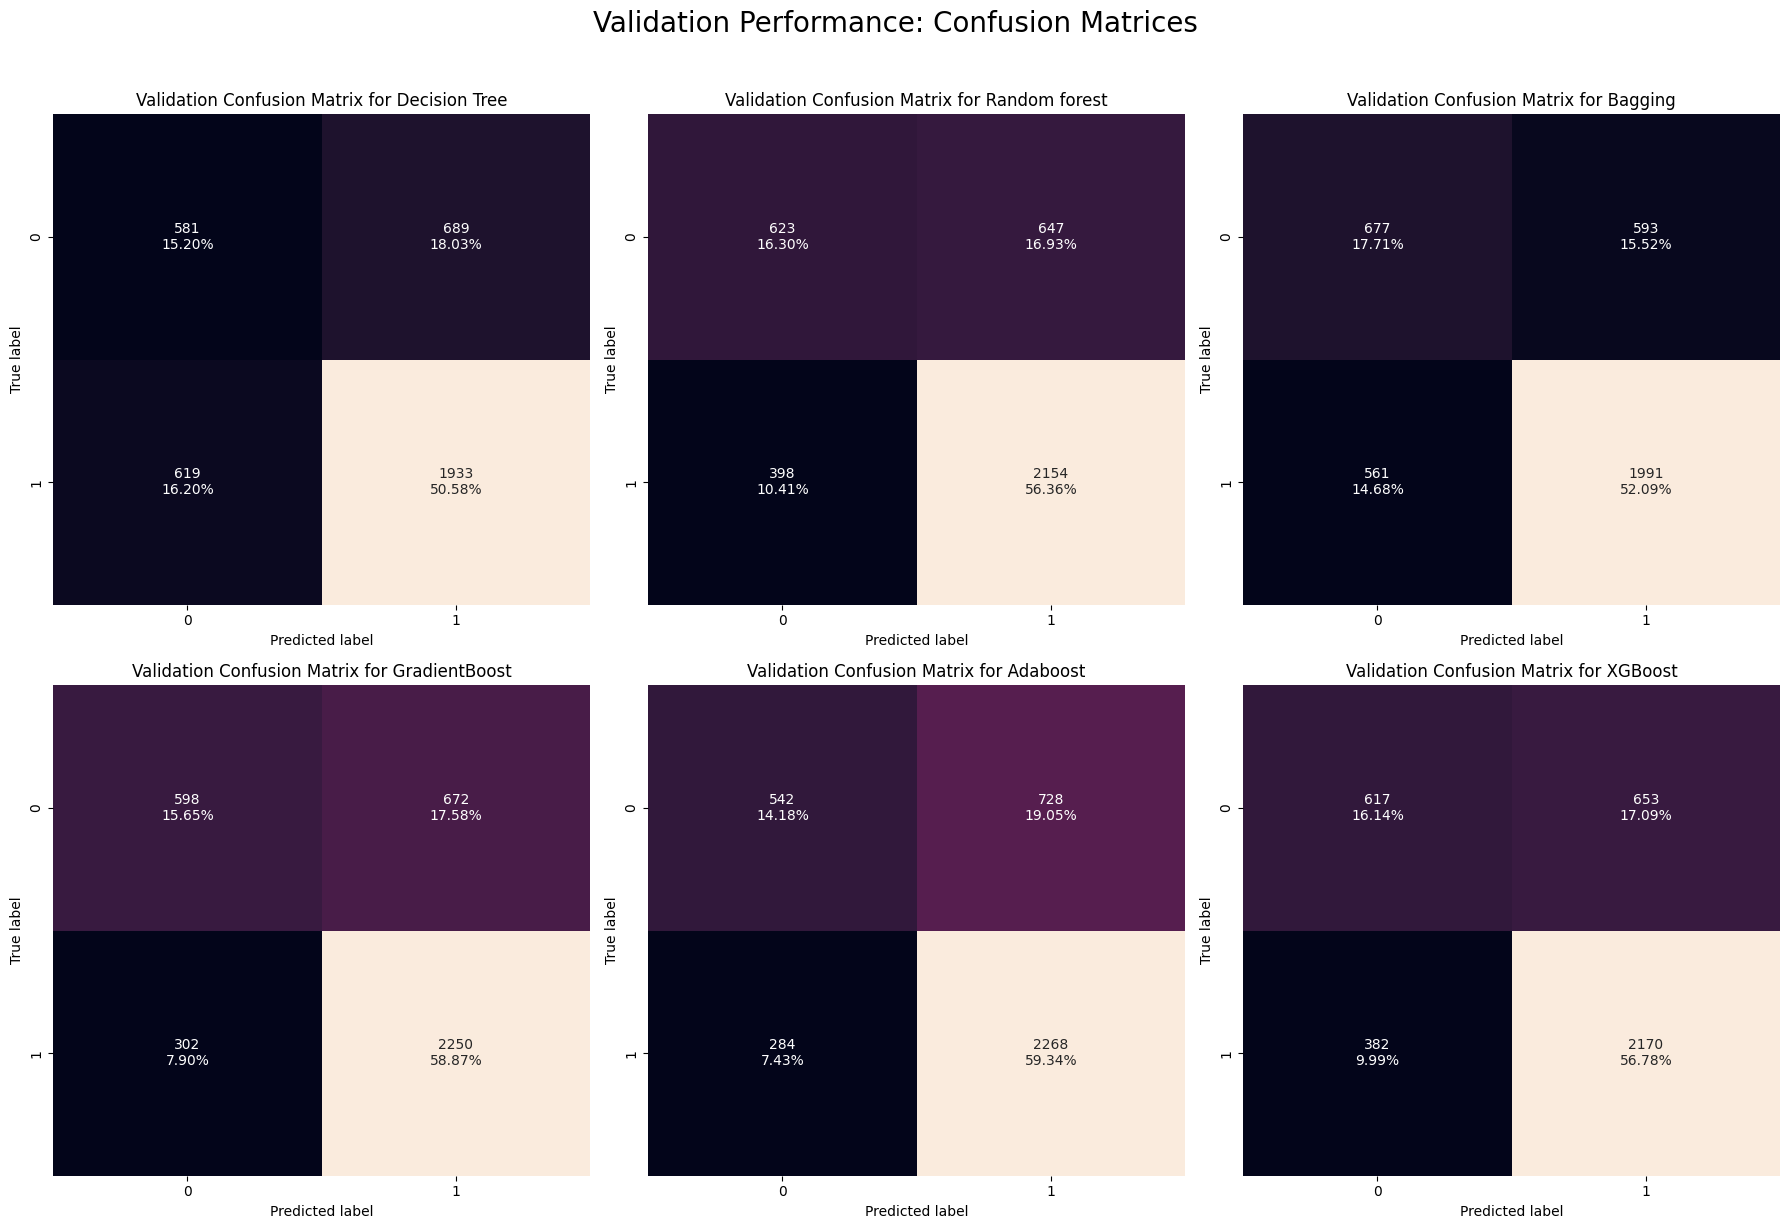

In [119]:
# Create the Grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.suptitle('Validation Performance: Confusion Matrices', fontsize=20, y=1.02)
axes = axes.flatten()

# Loop through models
for i, (name, model) in enumerate(models):
    # Fit the model
    model.fit(X_train, y_train)

    confusion_matrix_sklearn(model, X_val, y_val, ax=axes[i])

    # Set the title on the axis object directly
    axes[i].set_title(f"Validation Confusion Matrix for {name}")

# Handle extra empty plots (if any)
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observations:

The confusion matrix clearly shows the validations from metrics captured earlier. Tree based models overfits the data, while there's a major difference with validation data. Overall recall and precision are much more impacted

* Decision Tree
  - Confusion matrix shows around 18.03% False Positives, 16.20% False negatives
* Random Forest
  - Confusion matrix shows around 16.9% False Positives, 10.41% False negatives
* Bagging
  - Confusion matrix shows around 15.5% False Positives, 14.6% False negatives
* Gradient Boost
  - Confusion matrix shows around 17.58% False Positives, 7.9% False negatives
* Ada Boost
  - Confusion matrix shows around 19.05% False Positives, 7.43% False negatives
* XGBoost
  - Confusion matrix shows around 17.09% False Positives, 9.99% False negatives

Compare the model's performance

In [120]:
# Create DataFrames with Model as index
print("\n" + "=" * 70)
print("TRAINING vs VALIDATION COMPARISON")
print("=" * 70)
train_df_renamed = train_perf_df.add_prefix('Train_')
val_df_renamed = val_perf_df.add_prefix('Val_')
comparison_df = pd.concat([train_df_renamed, val_df_renamed], axis=1)
display(comparison_df.round(4))


TRAINING vs VALIDATION COMPARISON


,Train_Accuracy,Train_Recall,Train_Precision,Train_F1,Val_Accuracy,Val_Recall,Val_Precision,Val_F1
Decision Tree,1.00000,1.00000,1.00000,1.00000,0.65780,0.75740,0.73720,0.74720
Random forest,0.99990,0.99990,1.00000,1.00000,0.72660,0.84400,0.76900,0.80480
Bagging,0.98540,0.98670,0.99140,0.98910,0.69810,0.78020,0.77050,0.77530
GradientBoost,0.75880,0.88370,0.78300,0.83030,0.74520,0.88170,0.77000,0.82210
Adaboost,0.73970,0.88730,0.76200,0.81990,0.73520,0.88870,0.75700,0.81760
XGBoost,0.84140,0.92980,0.84760,0.88680,0.72920,0.85030,0.76870,0.80740


Insights:

- Based on the F1-Score, Gradient Boosting is currently the superior model on the original Data.

- It achieves the highest Validation F1 (0.822) demonstrating that it best balances the trade-off between avoiding legal risks (Precision) and minimizing talent loss (Recall).

- AdaBoost shows highes recall(0.88), followed with GradientBoost, almost similar recall and balancing F1 score.

### Model Building - Oversampled Data

Oversampling (using SMOTE) generates synthetic examples of the minority 'Denied' class to balance the dataset, ensuring the model learns to identify rejected applications just as effectively as certified ones.

Let's build this classification problem with below models on the oversampled data:

1. Decision Tree
2. Random Forest
3. Bagging
4. Ada Boost
5. Gradient Boost
6. XGBoost

Oversampling the data

In [121]:
print("Before Oversampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

# Perform SMOTE - Oversample training data
sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique

X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Certified': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'Denied': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Certified': 11913
Before Oversampling, counts of label 'Denied': 5923 

After Oversampling, counts of label 'Certified': 11913
After Oversampling, counts of label 'Denied': 11913 

After Oversampling, the shape of train_X: (23826, 21)
After Oversampling, the shape of train_y: (23826,) 



Observations:

1. After oversampling, it is evident that Denied class is adjusted to match with Certified class of training data (11913 each)
2. Overall shape of the over sampled training data is now 23826 rows and 21 columns

In [122]:
#Define all the models and capture performance of the models on training data

models = []  # Empty list to store all the models

#Appending models into the list
#Decision Tree Classifier
models.append(("Decision Tree (Over)",
               DecisionTreeClassifier(random_state=1, class_weight='balanced'))) #Evaluate with balanced class weight

#Random Forest Classifier
models.append(("Random forest (Over)",
               RandomForestClassifier(random_state=1, class_weight='balanced'))) #Evaluate with balanced class weight

#Bagging Classifier with Decision Tree
models.append(("Bagging (Over)",
               BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
#Evaluate with balanced class weight

#GradientBoost Classifier
models.append(("GradientBoost (Over)",
               GradientBoostingClassifier(random_state=1)))

#AdaBoost Classifier
models.append(("Adaboost (Over)",
               AdaBoostClassifier(random_state=1)))

#XGBoost Classifier
models.append(("XGBoost (Over)",
               XGBClassifier(random_state=1,eval_metric='logloss'))) #Ignore warnings with logloss



In [123]:
# Plot training performance and validation performance of all the models

train_scores = [] #Empty list to store training scores
val_scores = [] #Empty list to store validation scores

# Loop through models
for name, model in models:
    # Fit the model
    model.fit(X_train_over, y_train_over)

    # Training performance
    train_score = model_performance_classification_sklearn(model, X_train_over, y_train_over)
    # Set the index to the model name (currently it might be 0 or empty)
    train_score.index = [name]
    train_scores.append(train_score)

    # Validation performance
    val_score = model_performance_classification_sklearn(model, X_val, y_val)
    # Set the index to the model name
    val_score.index = [name]
    val_scores.append(val_score)

# Concatenate all rows (Result: Models as Index, Metrics as Columns)
over_train_perf_df = pd.concat(train_scores)
over_val_perf_df = pd.concat(val_scores)

# Transpose the DataFrames (Result: Metrics as Index, Models as Columns)
train_perf_final = over_train_perf_df.T
val_perf_final = over_val_perf_df.T

# Display
print("Training Performance:")
display(train_perf_final)

print("\nValidation Performance:")
display(val_perf_final)

Training Performance:


,Decision Tree (Over),Random forest (Over),Bagging (Over),GradientBoost (Over),Adaboost (Over),XGBoost (Over)
Accuracy,1.00000,0.99996,0.98833,0.81340,0.79640,0.87354
Recall,1.00000,0.99992,0.98472,0.86401,0.83808,0.92269
Precision,1.00000,1.00000,0.99188,0.78459,0.77359,0.84011
F1,1.00000,0.99996,0.98829,0.82239,0.80454,0.87947



Validation Performance:


,Decision Tree (Over),Random forest (Over),Bagging (Over),GradientBoost (Over),Adaboost (Over),XGBoost (Over)
Accuracy,0.66353,0.72240,0.70016,0.74516,0.72370,0.72187
Recall,0.74726,0.83307,0.77234,0.86677,0.83464,0.84757
Precision,0.74843,0.77001,0.77721,0.77723,0.77062,0.76243
F1,0.74784,0.80030,0.77476,0.81956,0.80135,0.80275


Observations:

* Massive Overfitting in Tree-Based Models
  - The Decision Tree, Random Forest, and Bagging Classifier are exhibiting severe overfitting.
  - **Decision Tree**
    - Achieved a perfect 1.0 (100%) on training data but dropped drastically to ~0.74 (74%) F1 score in Validation.
    - This suggests the tree memorized the training noise and failed to learn general patterns.
  - **Random Forest**
    - It has near-perfect training scores (~0.999) but drops to ~0.80 F1 score in Validation.
    - Recall, Accuracy also see a significant drop(0.83, 0.72) in validation.
    - While Precision dropped to 0.77 in validation
  - **Bagging**
    - It has near-perfect training scores (~0.98) but drops to ~0.77 F1 score in Validation.
    - While Recall, Precision dropped to 0.77, accuracy dropped further to 0.70 in validation


These models are currently too complex and overfitting. They need hyperparameter tuning to improve generalization.

* Boosting Models

  - Gradient Boosting and AdaBoost are performing much more reliably. XGBoost shows highest performance on training data
  - Gradient Boosting
    - The gap between Training F1 (0.82) and Validation F1 (0.819) is very small. This indicates a stable, robust model
    - This has highest recall on Validation(0.86), followed by XGBoost(0.84) and AdaBoost (0.83)
  - AdaBoost
    - The gap between Training F1 (0.804) and Validation F1 (0.801) is very small.
  - XGBoost Performance
    - It has higher Training F1 (0.879) compared to other boosting methods, indicating it captured more complexity.
    - However, it sees a noticeable drop in validation F1 (0.802)


Oversampled data performance is more or less similar to original data's performance. Sightly a bit under w.r.t original data's performance

Plot the confusion matrix on training data

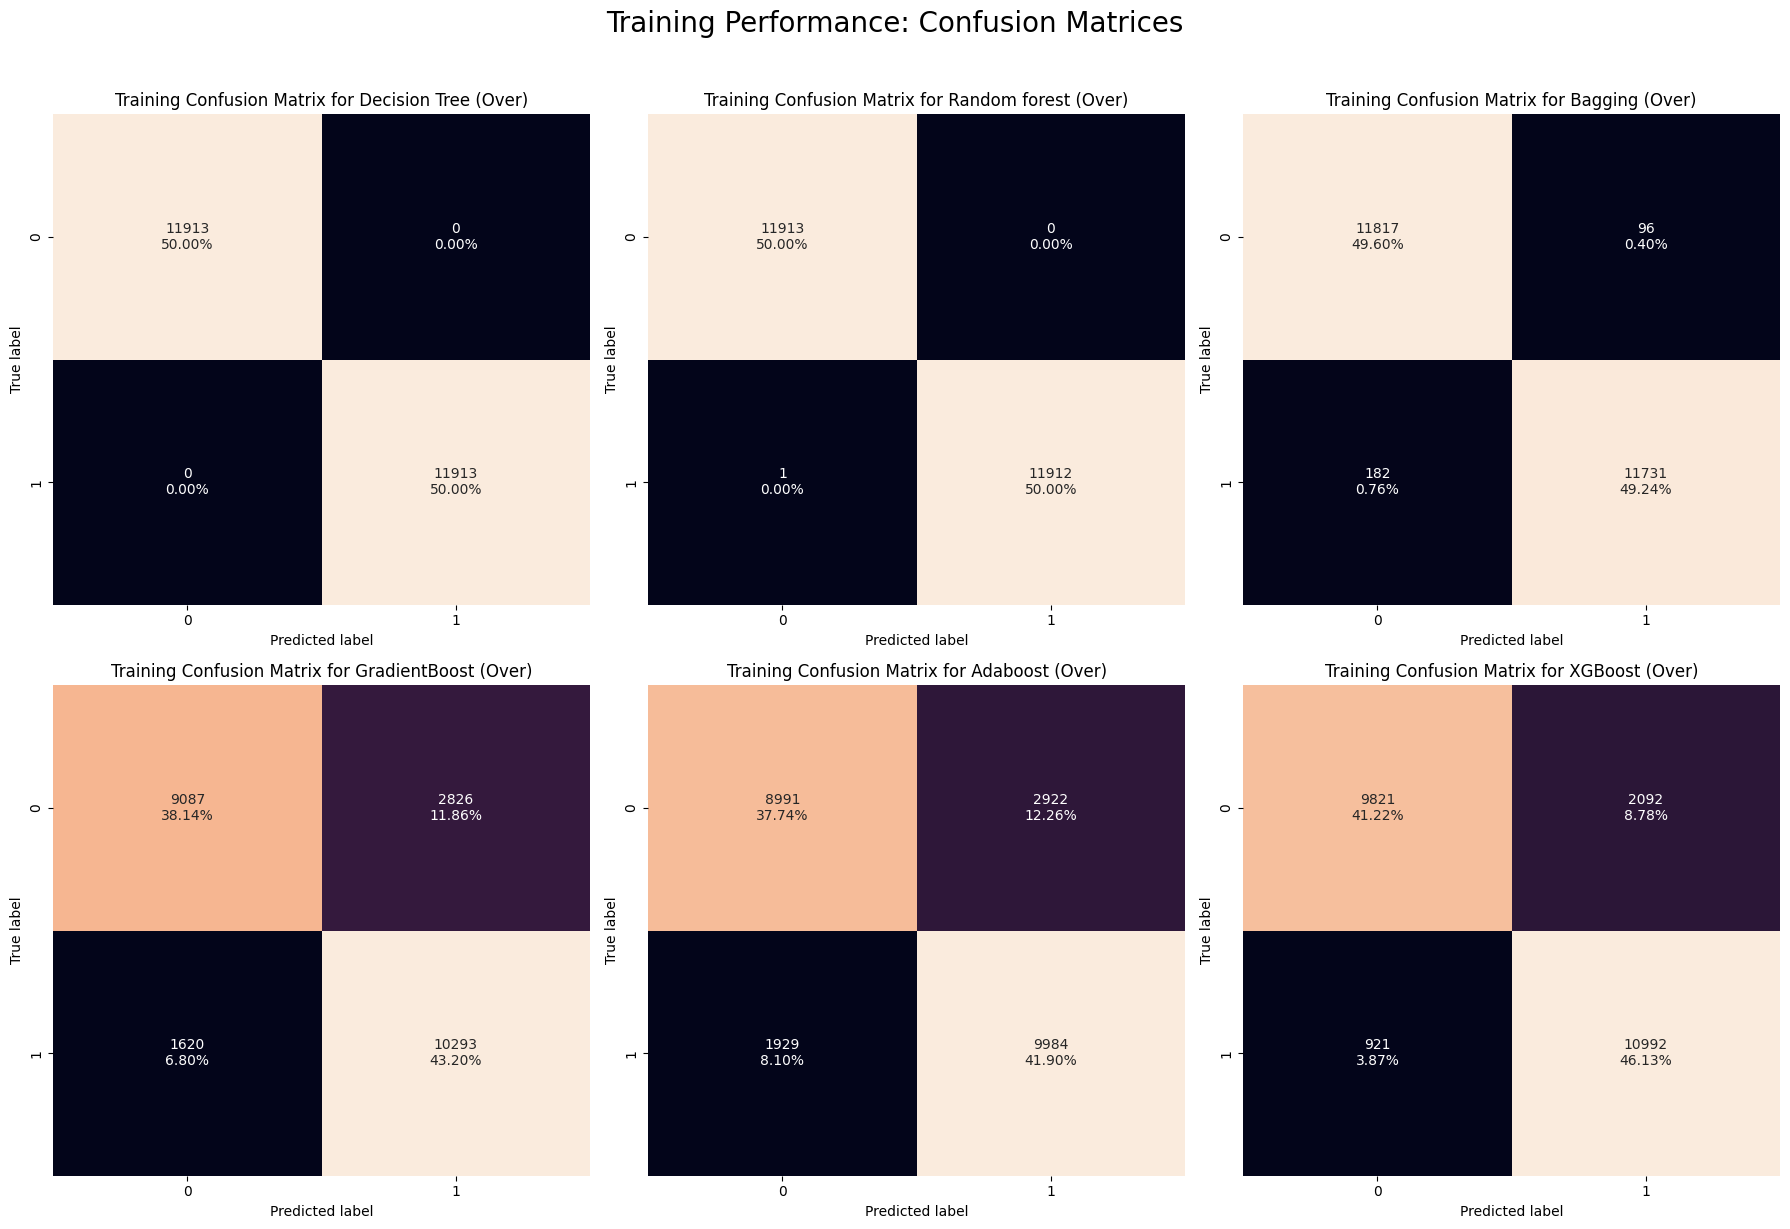

In [124]:
# Create the Grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.suptitle('Training Performance: Confusion Matrices', fontsize=20, y=1.02)
axes = axes.flatten()

# Loop through models
for i, (name, model) in enumerate(models):
    # Fit the model
    model.fit(X_train_over, y_train_over)

    confusion_matrix_sklearn(model, X_train_over, y_train_over, ax=axes[i])

    # Set the title on the axis object directly
    axes[i].set_title(f"Training Confusion Matrix for {name}")

# Handle extra empty plots (if any)
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observations:

* The confusion matrix clearly shows the validations from metrics captured above. Tree based models overfits the data

* Decision Tree
  - Perfectly overfits the training data (0% for FP and FN)
* Random Forest
  - Same as decision tree. Overfits the training data
* Bagging
  - Nearly overfitting the data. False Positives are around 0.4%, False Negatives are around 0.76%
* Gradient Boost
  - Confusion matrix shows around 11.86% False Positives, 6.8% False negatives
* Ada Boost
  - Confusion matrix shows around 12.26% False Positives, 8.1% False negatives
* XGBoost
  - Confusion matrix shows around 8.7% False Positives, 3.87% False negatives

Plot the confusion matrix on validation data

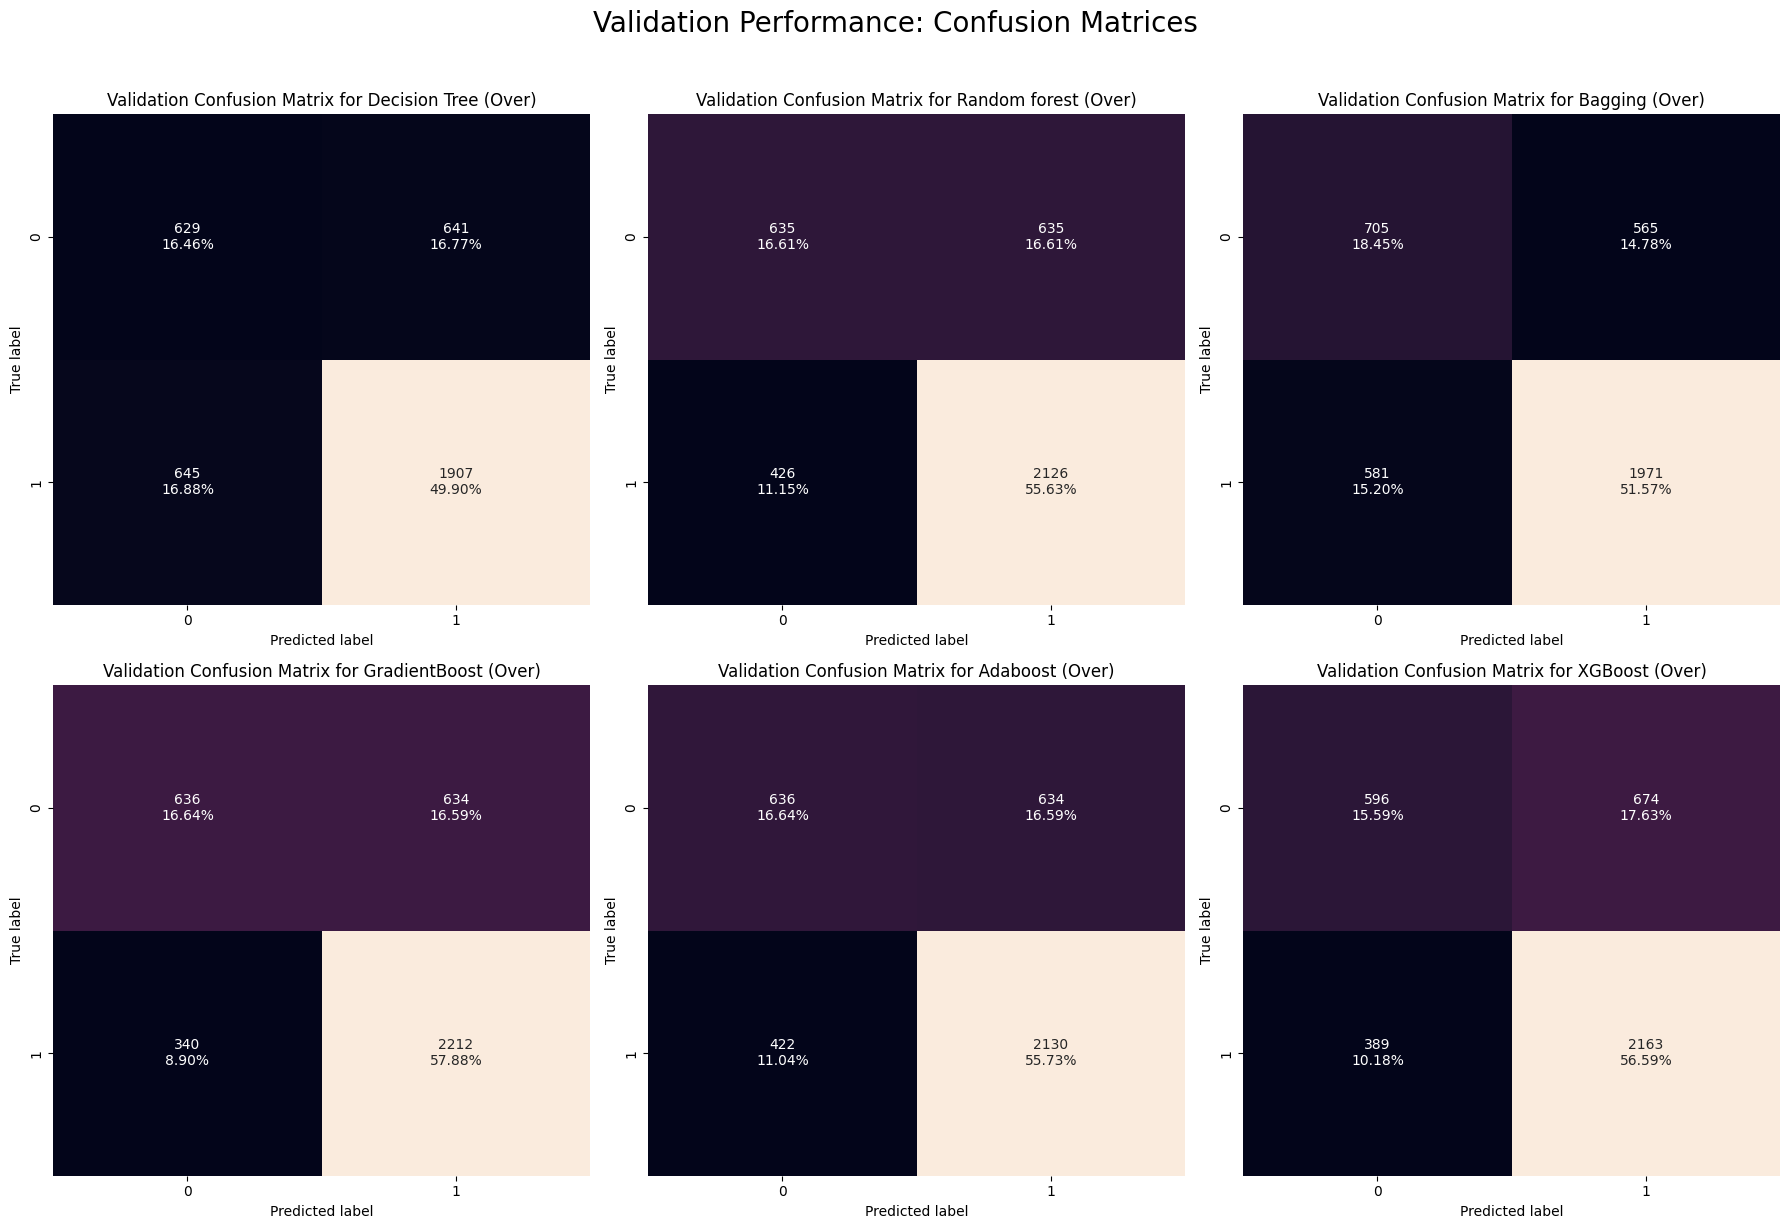

In [125]:
# Create the Grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.suptitle('Validation Performance: Confusion Matrices', fontsize=20, y=1.02)
axes = axes.flatten()

# Loop through models
for i, (name, model) in enumerate(models):
    # Fit the model
    model.fit(X_train_over, y_train_over)

    confusion_matrix_sklearn(model, X_val, y_val, ax=axes[i])

    # Set the title on the axis object directly
    axes[i].set_title(f"Validation Confusion Matrix for {name}")

# Handle extra empty plots (if any)
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observations:

The confusion matrix clearly shows the validations from metrics captured earlier. Tree based models overfits the data, while there's a major difference with validation data. Overall recall and precision are much more impacted

* Decision Tree
  - Confusion matrix shows around 16.77% False Positives, 16.88% False negatives
* Random Forest
  - Confusion matrix shows around 16.61% False Positives, 11.15% False negatives
* Bagging
  - Confusion matrix shows around 14.78% False Positives, 15.20% False negatives
* Gradient Boost
  - Confusion matrix shows around 16.59% False Positives, 8.9% False negatives
* Ada Boost
  - Confusion matrix shows around 16.59% False Positives, 11.04% False negatives
* XGBoost
  - Confusion matrix shows around 17.63% False Positives, 10.18% False negatives

Compare the model's performance

In [126]:
# Create DataFrames with Model as index
print("\n" + "=" * 70)
print("TRAINING vs VALIDATION COMPARISON")
print("=" * 70)
train_df_renamed = over_train_perf_df.add_prefix('Train_')
val_df_renamed = over_val_perf_df.add_prefix('Val_')
comparison_df = pd.concat([train_df_renamed, val_df_renamed], axis=1)
display(comparison_df.round(4))


TRAINING vs VALIDATION COMPARISON


,Train_Accuracy,Train_Recall,Train_Precision,Train_F1,Val_Accuracy,Val_Recall,Val_Precision,Val_F1
Decision Tree (Over),1.00000,1.00000,1.00000,1.00000,0.66350,0.74730,0.74840,0.74780
Random forest (Over),1.00000,0.99990,1.00000,1.00000,0.72240,0.83310,0.77000,0.80030
Bagging (Over),0.98830,0.98470,0.99190,0.98830,0.70020,0.77230,0.77720,0.77480
GradientBoost (Over),0.81340,0.86400,0.78460,0.82240,0.74520,0.86680,0.77720,0.81960
Adaboost (Over),0.79640,0.83810,0.77360,0.80450,0.72370,0.83460,0.77060,0.80140
XGBoost (Over),0.87350,0.92270,0.84010,0.87950,0.72190,0.84760,0.76240,0.80270


Insights:

- Based on the F1-Score, Gradient Boosting is currently the good model on the over-sampled Data.

- It achieves the highest Validation F1 (0.819) demonstrating that it best balances the trade-off between avoiding legal risks (Precision) and minimizing talent loss (Recall).

- Followed with XGBoost(0.802) and AdaBoost(0.801) algorithms, seems boosting algorithms works better on oversampled data

- Recall and Precision are balanced for boosting models and Random Forest. Which shows the good performance among others(Decision tree and Bagging)


However, GradientBoost (0.822) and AdaBoost (0.817) models with original data show better generalization.

This is likely because boosting algorithms iteratively focus on previously misclassified instances, effectively managing the imbalance.

### Model Building - Undersampled Data

Undersampling reduces the majority 'Certified' class to match the size of the minority 'Denied' class, balancing the dataset at the cost of potentially discarding valuable training information.

Let's build this classification problem with below models on the undersampled data:

1. Decision Tree
2. Random Forest
3. Bagging
4. Ada Boost
5. Gradient Boost
6. XGBoost

In [127]:
#Initiate RandomUnderSampler for undersampling

rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [128]:
print("Before Under Sampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Certified': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Certified': 11913
Before Under Sampling, counts of label 'Denied': 5923 

After Under Sampling, counts of label 'Certified': 5923
After Under Sampling, counts of label 'Denied': 5923 

After Under Sampling, the shape of train_X: (11846, 21)
After Under Sampling, the shape of train_y: (11846,) 



After undersampling, the Certified class samples are reduced to 5923 to match with Denied class samples

Observations:

1. After undersampling, the Certified class samples are reduced to 5923 to match with Denied class samples (5923 each)
2. Overall shape of the over sampled training data is now reduced to 11846 rows and 21 columns

In [129]:
#Define all the models and capture performance of the models on training data

models = []  # Empty list to store all the models

#Appending models into the list
#Decision Tree Classifier
models.append(("Decision Tree (Under)",
               DecisionTreeClassifier(random_state=1, class_weight='balanced'))) #Evaluate with balanced class weight

#Random Forest Classifier
models.append(("Random forest (Under)",
               RandomForestClassifier(random_state=1, class_weight='balanced'))) #Evaluate with balanced class weight

#Bagging Classifier with Decision Tree
models.append(("Bagging (Under)",
               BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
#Evaluate with balanced class weight

#GradientBoost Classifier
models.append(("GradientBoost (Under)",
               GradientBoostingClassifier(random_state=1)))

#AdaBoost Classifier
models.append(("Adaboost (Under)",
               AdaBoostClassifier(random_state=1)))

#XGBoost Classifier
models.append(("XGBoost (Under)",
               XGBClassifier(random_state=1,eval_metric='logloss'))) #Ignore warnings with logloss



In [130]:
# Plot training performance and validation performance of all the models

train_scores = [] #Empty list to store training scores
val_scores = [] #Empty list to store validation scores

# Loop through models
for name, model in models:
    # Fit the model
    model.fit(X_train_un, y_train_un)

    # Training performance
    train_score = model_performance_classification_sklearn(model, X_train_un, y_train_un)
    # Set the index to the model name (currently it might be 0 or empty)
    train_score.index = [name]
    train_scores.append(train_score)

    # Validation performance
    val_score = model_performance_classification_sklearn(model, X_val, y_val)
    # Set the index to the model name
    val_score.index = [name]
    val_scores.append(val_score)

# Concatenate all rows (Result: Models as Index, Metrics as Columns)
under_train_perf_df = pd.concat(train_scores)
under_val_perf_df = pd.concat(val_scores)

# Transpose the DataFrames (Result: Metrics as Index, Models as Columns)
train_perf_final = under_train_perf_df.T
val_perf_final = under_val_perf_df.T

# Display
print("Training Performance:")
display(train_perf_final)

print("\nValidation Performance:")
display(val_perf_final)

Training Performance:


,Decision Tree (Under),Random forest (Under),Bagging (Under),GradientBoost (Under),Adaboost (Under),XGBoost (Under)
Accuracy,1.00000,1.00000,0.98050,0.72286,0.69492,0.85472
Recall,1.00000,1.00000,0.96944,0.72953,0.72210,0.86037
Precision,1.00000,1.00000,0.99137,0.71993,0.68487,0.85075
F1,1.00000,1.00000,0.98028,0.72470,0.70299,0.85554



Validation Performance:


,Decision Tree (Under),Random forest (Under),Bagging (Under),GradientBoost (Under),Adaboost (Under),XGBoost (Under)
Accuracy,0.61355,0.67111,0.63762,0.70565,0.70120,0.68995
Recall,0.61795,0.66614,0.60384,0.71395,0.72375,0.70102
Precision,0.75854,0.80760,0.80470,0.82183,0.80867,0.80914
F1,0.68106,0.73008,0.68995,0.76410,0.76385,0.75121


Observations:

* Massive Overfitting in Tree-Based Models
  - The Decision Tree, Random Forest, and Bagging Classifier are exhibiting severe overfitting.
  - **Decision Tree**
    - Achieved a perfect 1.0 (100%) on training data but dropped drastically to ~0.68 (68%) F1 score in Validation.
    - This suggests the tree memorized the training noise and failed to learn general patterns.
  - **Random Forest**
    - It has perfect training scores (1.0) but drops to ~0.73 F1 score in Validation.
    - Recall, Accuracy also see a significant drop(0.66-0.67) in validation.
    - While Precision dropped to 0.80 in validation
  - **Bagging**
    - It has near-perfect training scores (~0.98) but drops to ~0.68 F1 score in Validation.
    - While Recall, Accuracy dropped to 0.60-0.63, accuracy Precision dropped to 0.80 in validation


These models are currently too complex and overfitting. They need hyperparameter tuning to improve generalization.

* Boosting Models

  - Gradient Boosting and AdaBoost are a bit better compared to tree models. XGBoost shows highest performance on training data
  - Gradient Boosting
    - The performance is better with Validation data (0.76) compared with training sample (0.72)
  - AdaBoost
    - The performance is better with Validation data (0.76) compared with training sample (0.70)
  - XGBoost Performance
    - It has higher Training F1 (0.85) compared to other boosting methods, indicating it captured more complexity.
    - However, it sees a bigger drop in validation F1 (0.75)


Gradient Boost and Ada Boost seems a bit better compared with other models

Plot the confusion matrix on training data

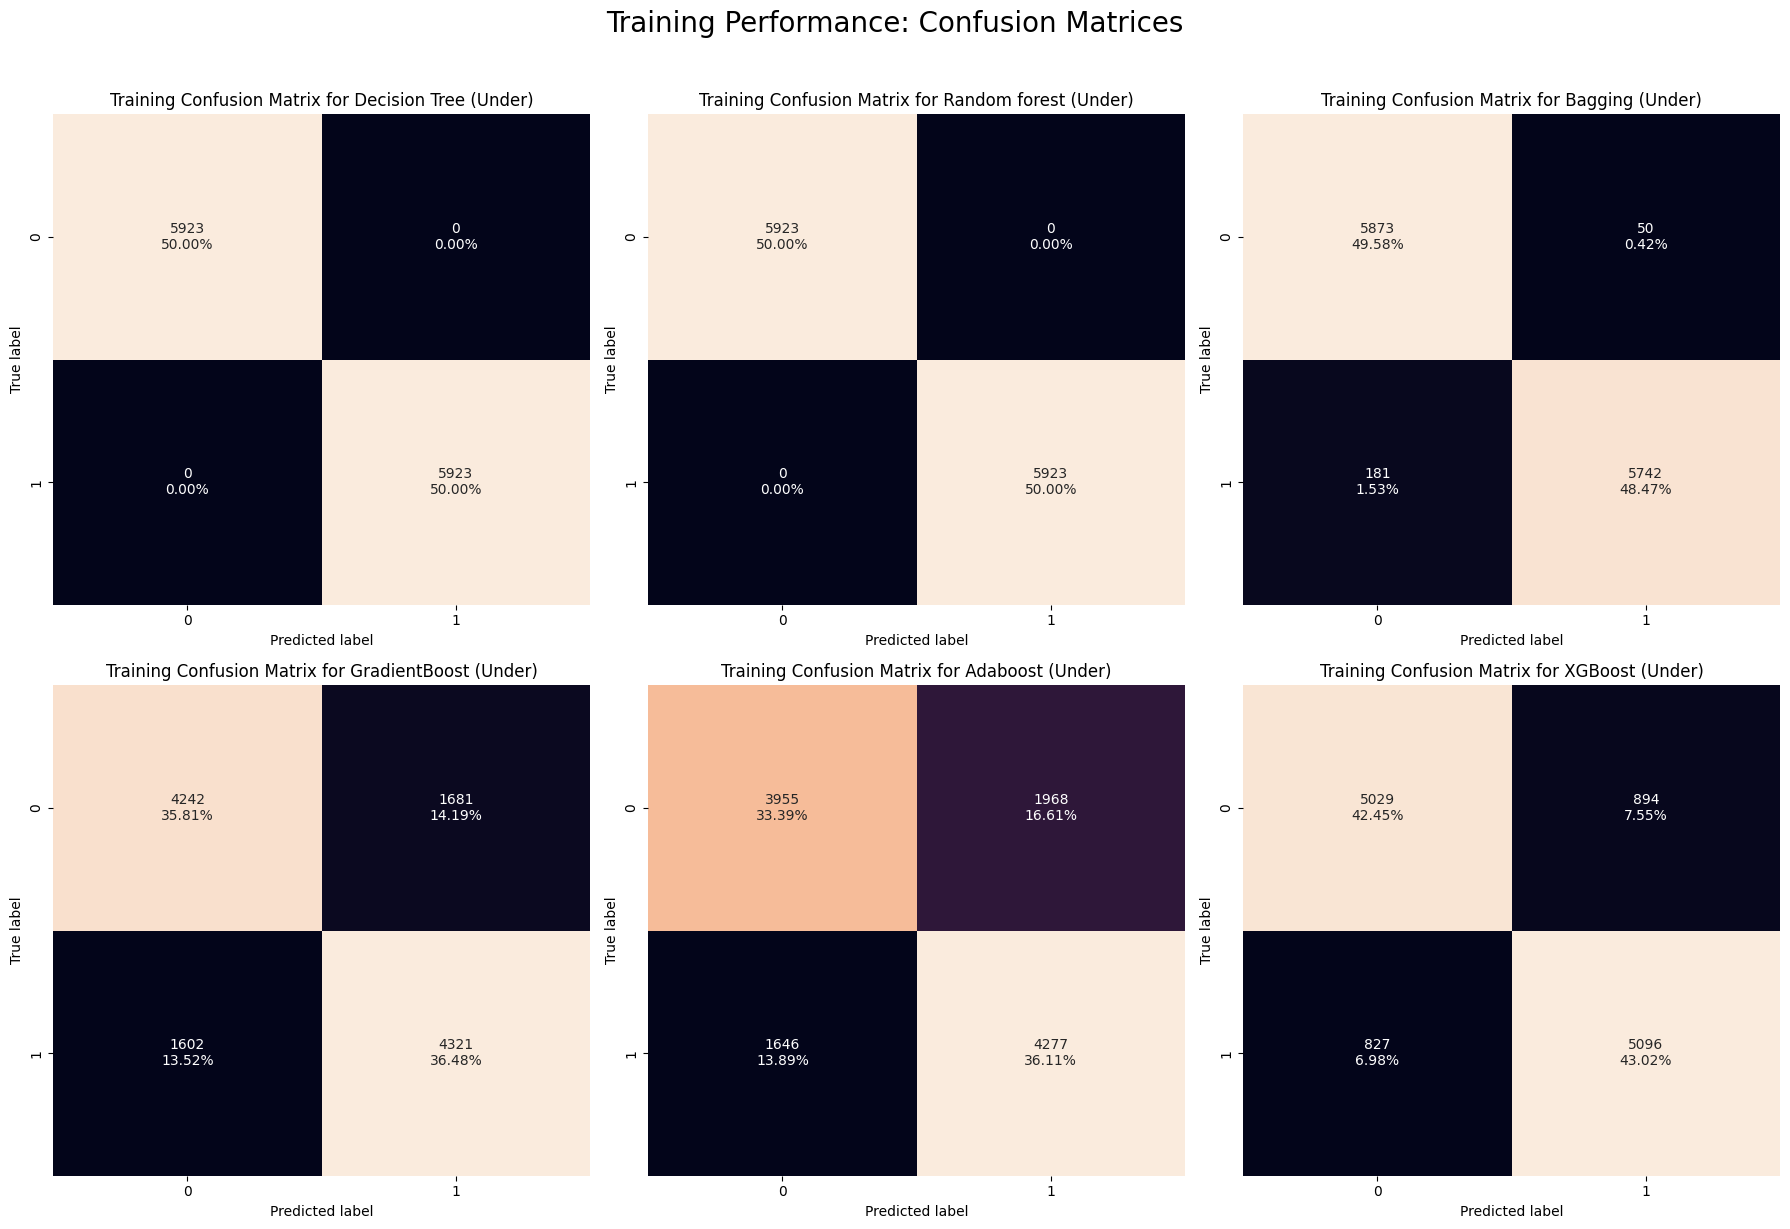

In [131]:
# Create the Grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.suptitle('Training Performance: Confusion Matrices', fontsize=20, y=1.02)
axes = axes.flatten()

# Loop through models
for i, (name, model) in enumerate(models):
    # Fit the model
    model.fit(X_train_un, y_train_un)

    confusion_matrix_sklearn(model, X_train_un, y_train_un, ax=axes[i])

    # Set the title on the axis object directly
    axes[i].set_title(f"Training Confusion Matrix for {name}")

# Handle extra empty plots (if any)
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observations:

* The confusion matrix clearly shows the validations from metrics captured above.

* Decision Tree
  - Perfectly overfits the training data (0% for FP and FN)
* Random Forest
  - Same as decision tree. Overfits the training data
* Bagging
  - Nearly overfitting the data. False Positives are around 0.42%, False Negatives are around 1.53%
* Gradient Boost
  - Confusion matrix shows around 14.19% False Positives, 13.52% False negatives
* Ada Boost
  - Confusion matrix shows around 16.61% False Positives, 13.89% False negatives
* XGBoost
  - Confusion matrix shows around 7.55% False Positives, 6.98% False negatives

Plot the confusion matrix on validation data

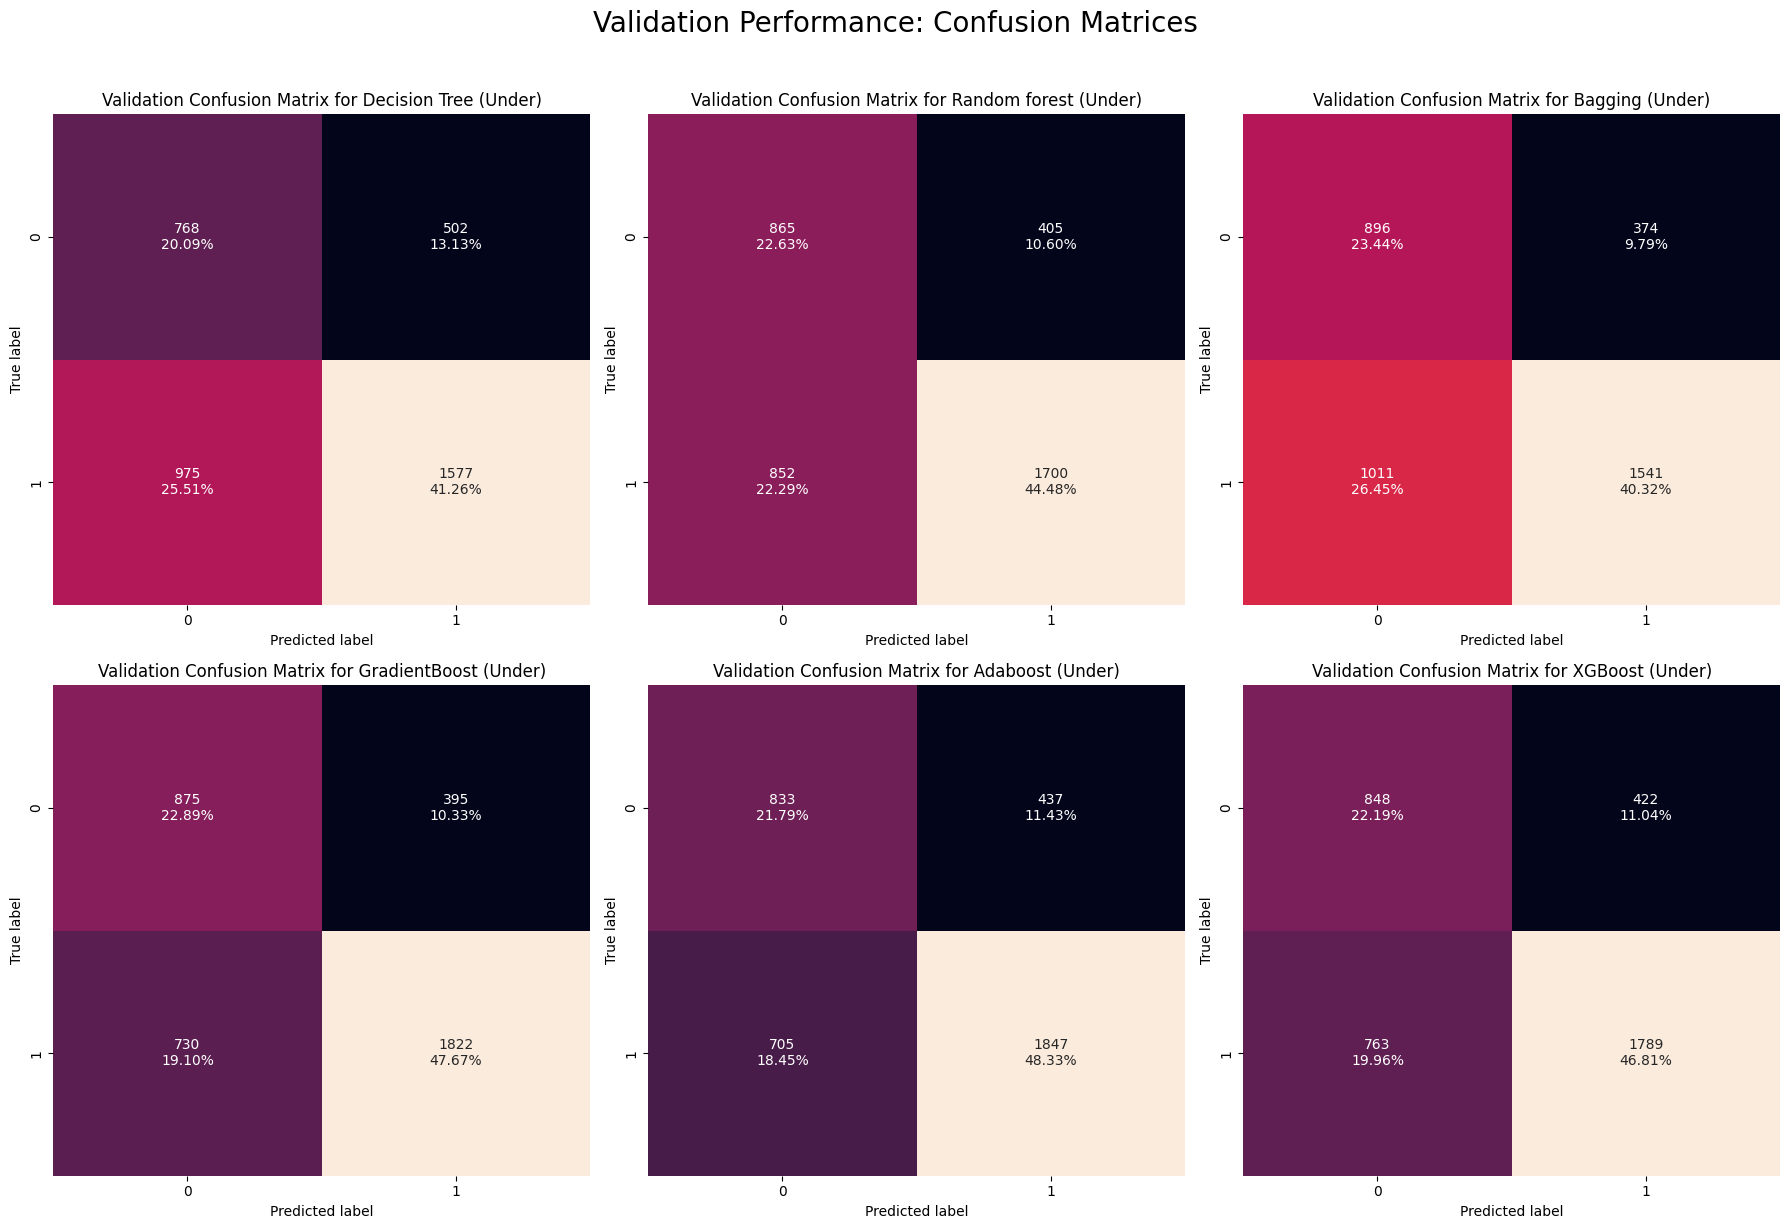

In [132]:
# Create the Grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.suptitle('Validation Performance: Confusion Matrices', fontsize=20, y=1.02)
axes = axes.flatten()

# Loop through models
for i, (name, model) in enumerate(models):
    # Fit the model
    model.fit(X_train_un, y_train_un)

    confusion_matrix_sklearn(model, X_val, y_val, ax=axes[i])

    # Set the title on the axis object directly
    axes[i].set_title(f"Validation Confusion Matrix for {name}")

# Handle extra empty plots (if any)
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observations:

The confusion matrix clearly shows the validations from metrics captured earlier. Tree based models overfits the data, while there's a major difference with validation data.

* Decision Tree
  - Confusion matrix shows around 13.13% False Positives, 25.51% False negatives
* Random Forest
  - Confusion matrix shows around 10.60% False Positives, 22.29% False negatives
* Bagging
  - Confusion matrix shows around 9.79% False Positives, 26.45% False negatives
* Gradient Boost
  - Confusion matrix shows around 10.33% False Positives, 19.10% False negatives
* Ada Boost
  - Confusion matrix shows around 11.43% False Positives, 18.45% False negatives
* XGBoost
  - Confusion matrix shows around 11.04% False Positives, 19.96% False negatives

Compare the model's performance

In [133]:
# Create DataFrames with Model as index
print("\n" + "=" * 70)
print("TRAINING vs VALIDATION COMPARISON")
print("=" * 70)
train_df_renamed = under_train_perf_df.add_prefix('Train_')
val_df_renamed = under_val_perf_df.add_prefix('Val_')
comparison_df = pd.concat([train_df_renamed, val_df_renamed], axis=1)
display(comparison_df.round(4))


TRAINING vs VALIDATION COMPARISON


,Train_Accuracy,Train_Recall,Train_Precision,Train_F1,Val_Accuracy,Val_Recall,Val_Precision,Val_F1
Decision Tree (Under),1.00000,1.00000,1.00000,1.00000,0.61360,0.61790,0.75850,0.68110
Random forest (Under),1.00000,1.00000,1.00000,1.00000,0.67110,0.66610,0.80760,0.73010
Bagging (Under),0.98050,0.96940,0.99140,0.98030,0.63760,0.60380,0.80470,0.68990
GradientBoost (Under),0.72290,0.72950,0.71990,0.72470,0.70570,0.71390,0.82180,0.76410
Adaboost (Under),0.69490,0.72210,0.68490,0.70300,0.70120,0.72370,0.80870,0.76390
XGBoost (Under),0.85470,0.86040,0.85080,0.85550,0.69000,0.70100,0.80910,0.75120


Insights:

- Based on the F1-Score(0.764), Gradient Boosting performs better on under sampled data.

- It achieves the highest Validation F1 (0.764) demonstrating that it best balances the trade-off between avoiding legal risks (Precision) and minimizing talent loss (Recall).

- Followed with AdaBoost(0.763) and XGBoost(0.751) algorithms, seems boosting algorithms works better on undersampled data


However, GradientBoost (0.819) and AdaBoost (0.801) models with over sampled data shows much better performance compared with under sampled data.

The lower performance of the undersampled models confirms that for this dataset, the loss of information from discarding majority class examples outweighed the benefits of balancing the classes.

##### Compare performance of all the models on validation data

In [134]:
# Group train results and validation results separately
train_all = pd.concat([train_perf_df, over_train_perf_df, under_train_perf_df])
val_all = pd.concat([val_perf_df, over_val_perf_df, under_val_perf_df])

# Now concat them side-by-side using axis=1
all_results = pd.concat([
    train_all.add_prefix("(Train)"),
    val_all.add_prefix("(Val)")
], axis=1)

print("="*60)
print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON - ALL 18 MODELS")
print("="*60)

all_results

COMPREHENSIVE MODEL PERFORMANCE COMPARISON - ALL 18 MODELS


,(Train)Accuracy,(Train)Recall,(Train)Precision,(Train)F1,(Val)Accuracy,(Val)Recall,(Val)Precision,(Val)F1
Decision Tree,1.00000,1.00000,1.00000,1.00000,0.65777,0.75745,0.73722,0.74720
Random forest,0.99994,0.99992,1.00000,0.99996,0.72658,0.84404,0.76901,0.80478
Bagging,0.98542,0.98674,0.99140,0.98906,0.69806,0.78017,0.77051,0.77531
GradientBoost,0.75880,0.88374,0.78304,0.83035,0.74516,0.88166,0.77002,0.82207
Adaboost,0.73968,0.88735,0.76204,0.81993,0.73522,0.88871,0.75701,0.81759
XGBoost,0.84144,0.92982,0.84758,0.88680,0.72920,0.85031,0.76869,0.80744
Decision Tree (Over),1.00000,1.00000,1.00000,1.00000,0.66353,0.74726,0.74843,0.74784
Random forest (Over),0.99996,0.99992,1.00000,0.99996,0.72240,0.83307,0.77001,0.80030
Bagging (Over),0.98833,0.98472,0.99188,0.98829,0.70016,0.77234,0.77721,0.77476
GradientBoost (Over),0.81340,0.86401,0.78459,0.82239,0.74516,0.86677,0.77723,0.81956


**Observations:**

1. Boosting Models:
    - Gradient Boosting, AdaBoost, and XGBoost consistently outperform others in F1-score, with top values around 0.82. They achieve high recall (0.85-0.89), meaning they effectively identify most certified cases, while maintaining reasonable precision (0.76-0.82) to avoid excessive false positives.
    - This makes them suitable for visa approval prediction

2. Tree-Based Models:
    - Single Decision Trees have the lowest F1-scores (0.68-0.75), with poor balance between recall and precision.
    - Ensembles (Random Forest, Bagging) improve this but still trail boosting methods, likely due to boosting's adaptive learning on errors.
    - Random Forest shows 0.805 as a good score, however not best compared with other models.

3. Impact of Data Resampling:
    - Original Data: Shows the highest F1 (up to 0.822), suggesting models handle imbalance well without resampling. (with class_weight parameter)
    - Oversampled Data: Similar to original, with minor F1 improvements in some boosting models (e.g., GradientBoost Over at 0.820) but slight drops in others.
    - Undersampled Data: Lowest overall F1 (0.68-0.76). This resampling evens classes but discards useful majority data, leading to underperformance.

4. Consistency Across Models:
    - F1 ranges from 0.68 (Decision Tree Under) to 0.82 (GradientBoost original).
    - Boosting methods show less variance across data types, indicating robustness.


Implications:

- The dataset's imbalance favors models with high recall.
- Undersampled models didn't perform quite well compared with other original/oversampled models
- No model exceeds 0.82 F1, suggesting room for tuning or feature improvements.

## Best Models Selection

Before selecting top models, it's evident that boosting models outperforms other models from the comparison matrix.

However, to ensure best Algorithm Diversity and High tuning potential, we will go with below models:

1. GradientBoost (Original over SMOTE)

    - **Reason:** Highest overall F1, with strong recall (0.82). It excels at capturing certified cases without too many false positives, making it a robust baseline for tuning.

2. AdaBoost (Original)

    - **Reason:** Shows better F1 (0.817), almost similar to GradientBoost. It's computationally lighter than GradientBoost and provides diversity in boosting approaches for comparison during tuning.

3. XGBoost (Original)

    - **Reason:** Although it slightly trailed AdaBoost (0.807) in the default run, XGBoost has far more hyperparameters than AdaBoost. We can find out how the model performs upon tuning.

4. RandomForest (Original)

    - **Reason:** Highest F1 outside boosting family; provides ensemble diversity to compare robustness and feature importance. Upon tuning, there can be changes of improvement in the performance

**Conclusion:**

1. Gradient Boosting on the original data achieves a significantly higher F1 score because it retains the natural distribution of the data set, whereas oversampling introduces additional data. Hence this is preferred over SMOTE (over sampled) model

2. Since all the top 3 models comes under boosting family, to ensure diversity in the models, we will also include Random Forest and tune accordingly

## Hyperparameter Tuning






Hyperparameter tuning systematically optimizes the model's external configurations (like tree depth and learning rate) to maximize the performance and prevent overfitting.


Based on the selected models above, we will proceed with the tuning for these models:
1. **Gradient Boost (Original)**
2. **XGBoost (Original)**
3. **RandomForest (Original)**
4. **AdaBoost (Original)**

### Tuning  Gradient Boosting Classifier

Tune Gradient Boosting classifier with hyperparameters

- init: An estimator object that is used to compute the initial predictions
- n_estimators: The maximum number of estimators at which boosting is terminated.
- learning_rate: Learning rate shrinks the contribution of each classifier by learning_rate value.
- max_features: The number of features to consider when looking for the best split.
- n_estimators and max_features control the number of trees and the diversity in the forest.
- subsample: Control the percentage of training data samples randomly selected to build each individual tree


In [135]:
%%time

# Define the model
gb_Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(200,300,50), # Defines 200, 250 as estimators
    "learning_rate": [0.2, 0.05, 1], # Defines learning rates
    "subsample": [0.8,0.9,1], # Defines subsamples
    "max_features": [0.4,0.6,0.8], #Defines max features
}

# Type of scoring used to compare parameter combinations
# Using f1_score directly as it was imported from sklearn.metrics
scorer = make_scorer(f1_score)

# Calling RandomizedSearchCV
# 30 Iterations, with 5 fold CV
randomized_cv = RandomizedSearchCV(estimator=gb_Model, param_distributions=param_grid, n_iter=30, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

# Fit the best algorithm to the data.
randomized_cv.fit(X_train, y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.9, 'n_estimators': np.int64(200), 'max_features': 0.8, 'learning_rate': 0.05, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.8249964615435894:
CPU times: user 7.93 s, sys: 660 ms, total: 8.59 s
Wall time: 8min 22s


**Tuning Result**

1. Best parameters idenfied as:
    - subsample: 0.9
    - n_estimators: 200
    - max_features: 0.8
    - learning_rate: 0.05
    - init: AdaBoostClassifier(random_state=1)
2. Best CV score: 0.824


In [136]:
#Tune GradientBoosting with the best parameters captured above

tuned_gbm = randomized_cv.best_estimator_

#Fit the tuned model
tuned_gbm.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_features=0.8,
                           n_estimators=np.int64(200), random_state=1,
                           subsample=0.9)

In [137]:
# Checking model's performance on training set

gbm_train = model_performance_classification_sklearn(
    tuned_gbm, X_train, y_train
)

gbm_train

,Accuracy,Recall,Precision,F1
0,0.75880,0.88408,0.78287,0.83040


In [138]:
# Checking model's performance on validation set

gbm_val = model_performance_classification_sklearn(
    tuned_gbm, X_val, y_val
)

gbm_val

,Accuracy,Recall,Precision,F1
0,0.74568,0.88166,0.77055,0.82237


Observations:

1. **Training Performance:** The Tuned Gradient Boosting model achieved an F1 score of 0.83 on the training data, driven by a strong Recall of 0.88 and Precision of 0.78.

2. **Generalization:** On the validation data, the model maintained an F1 score of 0.822. The minimal drop from training performance (< 1%) indicates that the model is highly stable and generalized well, without suffering from overfitting.

Plot Confusion Matrix for training data

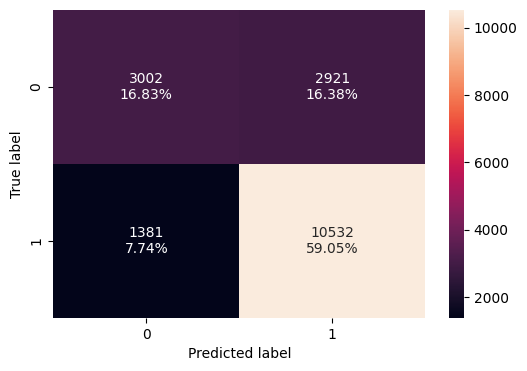

In [139]:
# Plot confusion matrix for tuned model on training data

confusion_matrix_sklearn(tuned_gbm, X_train, y_train)

Observations:

The model shows around 16.38% of false positives and 7.74% of false negatives

Plot Confusion Matrix for validation data

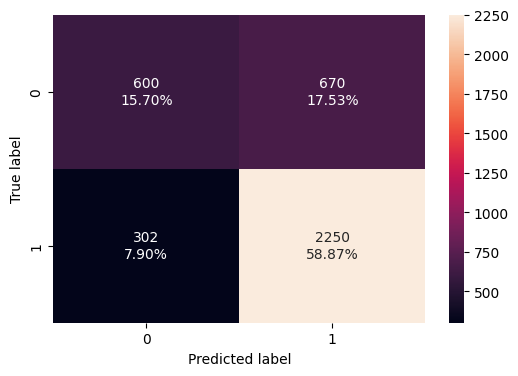

In [140]:
# Plot confusion matrix for tuned model on validation data

confusion_matrix_sklearn(tuned_gbm, X_val, y_val)

Observations:

The model shows around 17.53% of false positives and 7.90% of false negatives

**Insights:**

- Overall tuned gradient boosting model maintained an F1 score of 0.822 in validation.
- The minimal drop from training performance indicates that the model is highly stable and generalized well, without suffering from overfitting.

### Tuning AdaBoost Classifier

Tune AdaBoost classifier with hyperparameters


- estimator: The base estimator from which the boosted ensemble is built.
- n_estimators: The maximum number of estimators at which boosting is terminated.
- learning_rate: Learning rate shrinks the contribution of each classifier by learning_rate.

In [141]:
%%time

# defining model
ada_Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.5, 0.7, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = make_scorer(f1_score)

#Calling RandomizedSearchCV
# 30 Iterations, with 5 fold CV
randomized_cv = RandomizedSearchCV(estimator=ada_Model, param_distributions=param_grid, n_jobs = -1, n_iter=30, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(20), 'learning_rate': 0.7, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.8221273562205672:
CPU times: user 2.01 s, sys: 187 ms, total: 2.2 s
Wall time: 49.9 s


**Tuning Result**

1. Best parameters idenfied as:
    - n_estimators: 20
    - learning_rate: 0.7
    - estimator: DecisionTreeClassifier(max_depth=3, random_state=1)
2. Best CV score: 0.822


In [142]:
#Tune AdaBooster with the best parameters captured above
tuned_adb = randomized_cv.best_estimator_

#Fit the model on training data
tuned_adb.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.7, n_estimators=np.int64(20),
                   random_state=1)

In [143]:
# Checking model's performance on training set
adb_train = model_performance_classification_sklearn(tuned_adb, X_train, y_train)
adb_train

,Accuracy,Recall,Precision,F1
0,0.74821,0.88030,0.77383,0.82364


In [144]:
# Checking model's performance on validation set
adb_val = model_performance_classification_sklearn(tuned_adb, X_val, y_val)
adb_val

,Accuracy,Recall,Precision,F1
0,0.74280,0.88401,0.76656,0.82111


Observations:

1. **Training Performance:** The Tuned Ada Boosting model achieved an F1 score of 0.823 on the training data, driven by a Recall of 0.88 and Precision of 0.77.

2. **Generalization:** On the validation data, the model maintained an F1 score of 0.821. The minimal drop from training performance indicates that the model is highly stable and generalized well, without suffering from overfitting.

Plot Confusion Matrix for training data

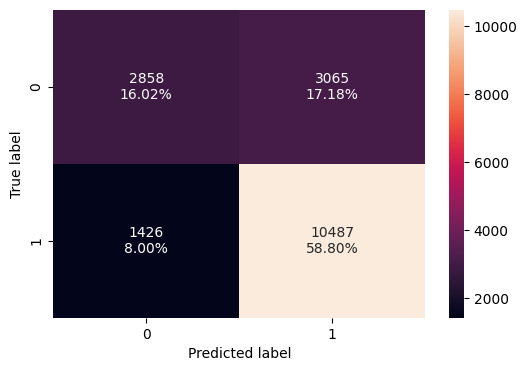

In [145]:
# Plot confusion matrix for tuned model on training data

confusion_matrix_sklearn(tuned_adb, X_train, y_train)

Observations:

The model shows around 17.18% of false positives and 8% of false negatives

Plot Confusion Matrix for validation data

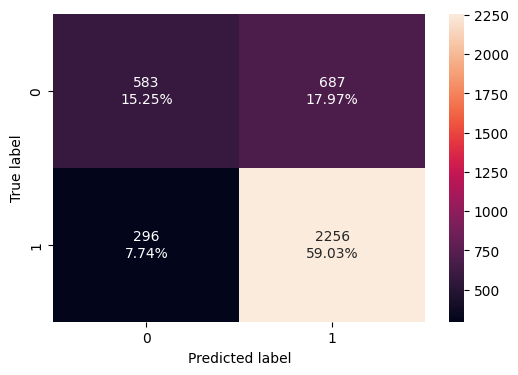

In [146]:
# Plot confusion matrix for tuned model on validation data

confusion_matrix_sklearn(tuned_adb, X_val, y_val)

Observations:

The model shows around 17.97% of false positives and 7.74% of false negatives

**Insights:**

- Overall tuned Ada boosting model maintained an F1 score of 0.822 in validation
- The minimal drop from training performance indicates that the model is highly stable and generalized well, without suffering from overfitting.

### Tuning Random Forest Classifier

Tune Random Forest classifier with hyperparameters


- n_estimators: It defines the number of trees in the forest.
- max_features: The number of features to consider when splitting a node. This helps control overfitting.
- max_depth: Controls the maximum number of levels, or splits, in each individual decision tree within the forest
- max_samples: Determines how much of the dataset is given to each individual tree
- min_samples_leaf: Minimum number of samples required to be present in a leaf node

In [147]:
%%time

# Choose the type of classifier.
rf_Model = RandomForestClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    "n_estimators": [150,200,250],
    "min_samples_leaf": np.arange(5, 10),
    "max_samples": np.arange(0.3, 0.7, 0.1),
    "max_depth":np.arange(3,4,5),
    "max_features": [0.5, 1]
    }

# Type of scoring used to compare parameter combinations
scorer = make_scorer(f1_score)

# Run the random search
randomized_cv = RandomizedSearchCV(rf_Model, parameters, n_iter=30, scoring=scorer, cv=5, random_state = 1, n_jobs = -1, verbose = 2)
# using n_iter = 30, so randomized search will try 30 different combinations of hyperparameters

randomized_cv.fit(X_train, y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters are {'n_estimators': 150, 'min_samples_leaf': np.int64(6), 'max_samples': np.float64(0.6000000000000001), 'max_features': 0.5, 'max_depth': np.int64(3)} with CV score=0.8200604623774618:
CPU times: user 3.05 s, sys: 259 ms, total: 3.31 s
Wall time: 2min 6s


**Tuning Result**

1. Best parameters idenfied as:
    - min_samples_leaf: 6
    - max_samples: 0.6
    - max_features: 0.5
    - n_estimators: 150
    - max_depth: 3
2. Best CV score: 0.820


In [148]:
# Tune RandomForest with the best parameters captured above
rf_tuned = randomized_cv.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

RandomForestClassifier(max_depth=np.int64(3), max_features=0.5,
                       max_samples=np.float64(0.6000000000000001),
                       min_samples_leaf=np.int64(6), n_estimators=150,
                       random_state=1)

In [149]:
# Checking model's performance on training set
rf_train = model_performance_classification_sklearn(
    rf_tuned, X_train, y_train
)

rf_train

,Accuracy,Recall,Precision,F1
0,0.73503,0.90422,0.75030,0.82010


In [150]:
# Checking model's performance on validation set
rf_val = model_performance_classification_sklearn(rf_tuned, X_val, y_val)
rf_val

,Accuracy,Recall,Precision,F1
0,0.72868,0.90870,0.74256,0.81727


Observations:

1. **Training Performance:** The Tuned Random Forest model achieved an F1 score of 0.820 on the training data, driven by a Recall of 0.90 and Precision of 0.75.

2. **Generalization:** On the validation data, the model maintained an F1 score of 0.817, maintaining same recall(0.90), but a slight reduce in Precision(0.74).

Plot Confusion Matrix for training data

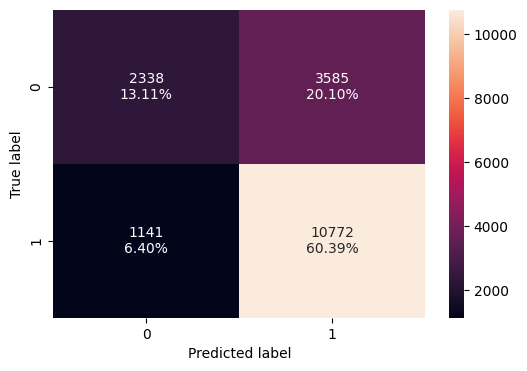

In [151]:
# Plot confusion matrix for tuned model on training data

confusion_matrix_sklearn(rf_tuned, X_train, y_train)

Observations:

The model shows around 20.1% of false positives and 6.4% of false negatives

Plot Confusion Matrix for validation data

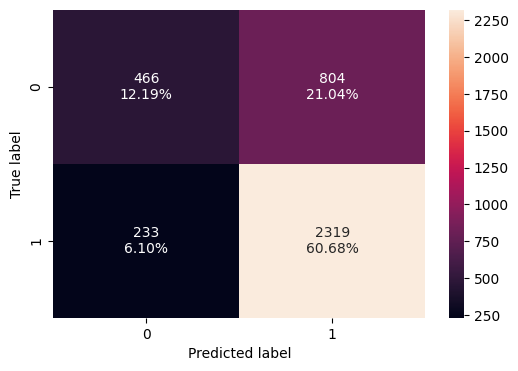

In [152]:
# Plot confusion matrix for tuned model on validation data

confusion_matrix_sklearn(rf_tuned, X_val, y_val)

Observations:

The model shows around 21.04% of false positives and 6.1% of false negatives

**Insights:**

- Overall tuned Random Forest model maintained an F1 score of 0.81 in validation
- The minimal drop from training performance indicates that the model is highly stable and generalized well, without suffering from overfitting.

### Tuning XGBoost Classifier

Tune XGBoost classifier with hyperparameters

- n_estimators: The total number of sequential trees to build; we tune this to find the balance where the model learns the signal without memorizing the noise.

- learning_rate: Controls how much each new tree corrects the previous errors

- scale_pos_weight: A critical parameter for our imbalanced dataset that increases the weight of the minority class to help the model identify "Denied" cases.

- gamma: A regularization parameter that acts as a "pruning" mechanism, specifying the minimum loss reduction required to make a new split in a tree.

- subsample: The fraction of training data randomly sampled for each tree; used to introduce variation and prevent the model from overfitting to specific instances.

- colsample_bytree: Defines the fraction of features (columns) to randomly subsample when constructing each new tree

- colsample_bylevel: Subsample ratio of columns for each level

In [153]:
%%time

# Define the model
xgb_tuned = XGBClassifier(random_state=1, eval_metric='logloss')

# Grid of parameters to choose from
parameters = {"n_estimators": np.arange(10,100,20),
              "scale_pos_weight":[0,1,2,5],
              "subsample":[0.5,0.7,0.9,1],
              "learning_rate":[0.01,0.1,0.2,0.05],
              "gamma":[0,1,3],
              "colsample_bytree":[0.5,0.7,0.9,1],
              "colsample_bylevel":[0.5,0.7,0.9,1]}


# Type of scoring used to compare parameter combinations
scorer = make_scorer(f1_score)

# Run the randomized search
rand_xgb = RandomizedSearchCV(xgb_tuned, parameters, n_iter=30, scoring=scorer, cv=5, n_jobs=-1, random_state=1)
# using n_iter = 30, so randomized search will try 30 different combinations of hyperparameters
# by default, n_iter = 10

rand_xgb = rand_xgb.fit(X_train, y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 150, 'min_samples_leaf': np.int64(6), 'max_samples': np.float64(0.6000000000000001), 'max_features': 0.5, 'max_depth': np.int64(3)} with CV score=0.8200604623774618:
CPU times: user 1.26 s, sys: 174 ms, total: 1.43 s
Wall time: 20.6 s


**Tuning Result**

1. Best parameters idenfied as:
    - min_samples_leaf: 6
    - max_samples: 0.6
    - max_features: 0.5
    - max_depth: 3
    - n_estimators: 150
    - init: AdaBoostClassifier
2. Best CV score: 0.820


In [154]:
# Set the xgb_tuned to the best combination of parameters
xgb_tuned = rand_xgb.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.5, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(50), n_jobs=None,
              num_parallel_tree=None, ...)

In [155]:
# Calculating different metrics on train set

xgboost_train = model_performance_classification_sklearn(
    xgb_tuned, X_train, y_train
)
print("Training performance:")
xgboost_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.76121,0.89415,0.78037,0.83339


In [156]:
# Calculating different metrics on validation set
xgboost_val = model_performance_classification_sklearn(xgb_tuned, X_val, y_val)
print("Validation performance:")
xgboost_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.74385,0.88793,0.76580,0.82236


Observations:

1. **Training Performance:** The Tuned XGBoost model achieved an F1 score of 0.833 on the training data, driven by a Recall of 0.89 and Precision of 0.78.

2. **Generalization:** On the validation data, the model maintained an F1 score of 0.822, Recall (0.88), Precision(0.76).

The minimal drop from training performance indicates that the model is highly stable and generalized well, without suffering from overfitting.

Plot Confusion Matrix for training data

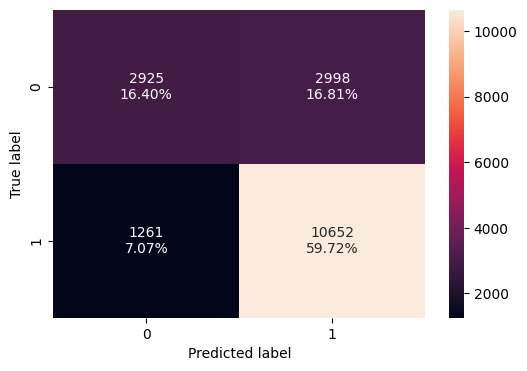

In [157]:
# Plot confusion matrix for tuned model on training data

confusion_matrix_sklearn(xgb_tuned, X_train, y_train)

Observations:

The model shows around 16.81% of false positives and 7.07% of false negatives

Plot Confusion Matrix for validation data

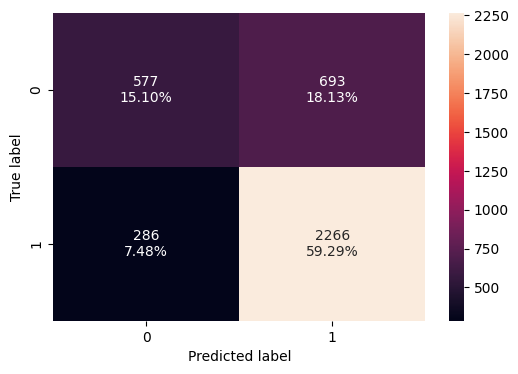

In [158]:
# Plot confusion matrix for tuned model on validation data

confusion_matrix_sklearn(xgb_tuned, X_val, y_val)

Observations:

The model shows around 18.13% of false positives and 7.48% of false negatives

**Insights:**

- Overall tuned XGBoost model maintained an F1 score of 0.822 in validation
- The minimal drop from training performance indicates that the model is highly stable and generalized well, without suffering from overfitting.

## Model Comparison and Final Model Selection

We will now compare the tuned model performances and select final model

In [159]:
# Training performance comparison

models_train_comp_df = pd.concat(
    [
        gbm_train.T,
        adb_train.T,
        rf_train.T,
        xgboost_train.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting (Original)",
    "Ada boosting (Original)",
    "Random Forest (Original)",
    "XGBoost (Original)"
]
print("Training performance comparison: \n")
models_train_comp_df

Training performance comparison: 



,Gradient boosting (Original),Ada boosting (Original),Random Forest (Original),XGBoost (Original)
Accuracy,0.75880,0.74821,0.73503,0.76121
Recall,0.88408,0.88030,0.90422,0.89415
Precision,0.78287,0.77383,0.75030,0.78037
F1,0.83040,0.82364,0.82010,0.83339


**Observations on training data:**

- XGBoost achieves the highest F1 (0.833) and is nearly tied with Gradient Boosting; suggesting excellent balance for imbalanced data.
- Gradient Boosting has the second highest F1 (0.830) shows that it performs consistently well, outperforming AdaBoost and Random Forest, indicating robustness without over-prioritizing recall.
- Random Forest has the best recall (0.904), minimizing missed certified cases, but its lower precision (0.750) and accuracy (0.735) lead to a slightly reduced F1 (0.820), potentially due to more false positives.
- AdaBoost shows next best F1 (0.82), but lags in accuracy and precision compared to others.
- Boosting models (Gradient, Ada, XG) performed well on training data


In [160]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [   gbm_val.T,
        adb_val.T,
        rf_val.T,
        xgboost_val.T
    ], axis=1,
)
models_val_comp_df.columns = [
    "Gradient boosting (Original)",
    "Ada boosting (Original)",
    "Random Forest (Original)",
    "XGBoost (Original)"
]
print("Validation performance comparison: \n")
models_val_comp_df

Validation performance comparison: 



,Gradient boosting (Original),Ada boosting (Original),Random Forest (Original),XGBoost (Original)
Accuracy,0.74568,0.74280,0.72868,0.74385
Recall,0.88166,0.88401,0.90870,0.88793
Precision,0.77055,0.76656,0.74256,0.76580
F1,0.82237,0.82111,0.81727,0.82236


**Observations on validation data:**

- Gradient Boosting and XGBoost lead in balance:
  - Both achieve nearly identical top F1-scores (0.822), with Gradient Boosting slightly edging in accuracy (0.746) and precision (0.771)
- XGBoost matches closely demonstrating strong overall performance for handling imbalanced validation sets through effective error correction.
- Random Forest stands out with the highest recall (0.909), excelling at capturing certified cases and minimizing false negatives, but its lower precision (0.743) and accuracy (0.729) result in a slightly reduced F1 (0.817), indicating more false positives compared to boosting methods.
- AdaBoost shows strong recall (0.884), nearly matching Random Forest, with a good F1 (0.821) and precision (0.767), making it a reliable lightweight option, though it lags slightly in accuracy (0.743) behind Gradient Boosting and XGBoost.
- The boosting models (Gradient, Ada, XG) perform closely in F1 (0.821-0.822) and accuracy (0.743-0.746), outperforming Random Forest overall, which highlights boosting's consistency in validation


## Final Model Selection: XGBoost

Both XGBoost and Gradient Boosting achieved identical performance with the validation dataset.

> We will proceed with **XGBoost** as the final model for this EasyVisa project.


The selection is driven by the following project-specific considerations:

*   **Optimized Balance:**
    - In the validation results, XGBoost achieved a **Recall of 0.8879**, slightly higher than Gradient Boosting.
    - Higher recall for 'Certified' cases means the model is better at identifying eligible workers, directly minimizing **talent loss** for U.S. businesses.
*   **Robustness to Data Imbalance:**
    - The dataset has a significant class imbalance (67% Certified vs. 33% Denied).
    - XGBoost's validation F1-score of **0.822** (similar to GB) demonstrates its ability to learn from this skewed distribution without the need for synthetic oversampling (SMOTE), ensuring predictions remain grounded.
*   **Scalability for Processing Volumes:**
    - The problem statement highlights an increasing volume of applications (nearly 1.7 million positions).
    - XGBoost's computational efficiency ensures that the applications can be processed with higher volumes in a scalable manner while maintaining consistent performance.
*   **Stable Generalization:**
    - The minimal gap between the training F1-score and the validation F1-score indicates that the model has successfully captured the underlying patterns of visa approvals rather than just memorizing the training data.


Considering robustness, scalability and optimized decision boundary features, we will be proceeding with XGBoost as our final model

## Model Performance on Test Data

Now, let's find out the performance of XGBoost on test data

In [161]:
# Calculating different metrics on test set

xgboost_test = model_performance_classification_sklearn(
    xgb_tuned, X_test, y_test
)
print("Test performance:")
xgboost_test

Test performance:


,Accuracy,Recall,Precision,F1
0,0.74882,0.88288,0.77324,0.82443


Observations:

- Generalization & Stability:

  - The model achieved an F1 score of 0.824 on the Test data, which is slightly higher than the Validation score (~0.822). This performance consistency confirms that the model is robust and performs reliably on completely unseen data.

- Regularization:

  - The hyperparameter tuning successfully prevented overfitting, ensuring the model learns actual patterns rather than memorizing training noise.

- Balanced decision boundary:

  - The simultaneous improvement in Precision(0.77) and Accuracy(0.74) indicates that the model has refined its 'approval criteria', while Recall(0.88) remains almost similar.
  - It is effectively balancing Legal Risk (avoiding False Positives) with Talent Acquisition (maintaining high Recall), making it highly effective.

### Feature Importance

Overview of the importance of features used in building tuned XGBoost model

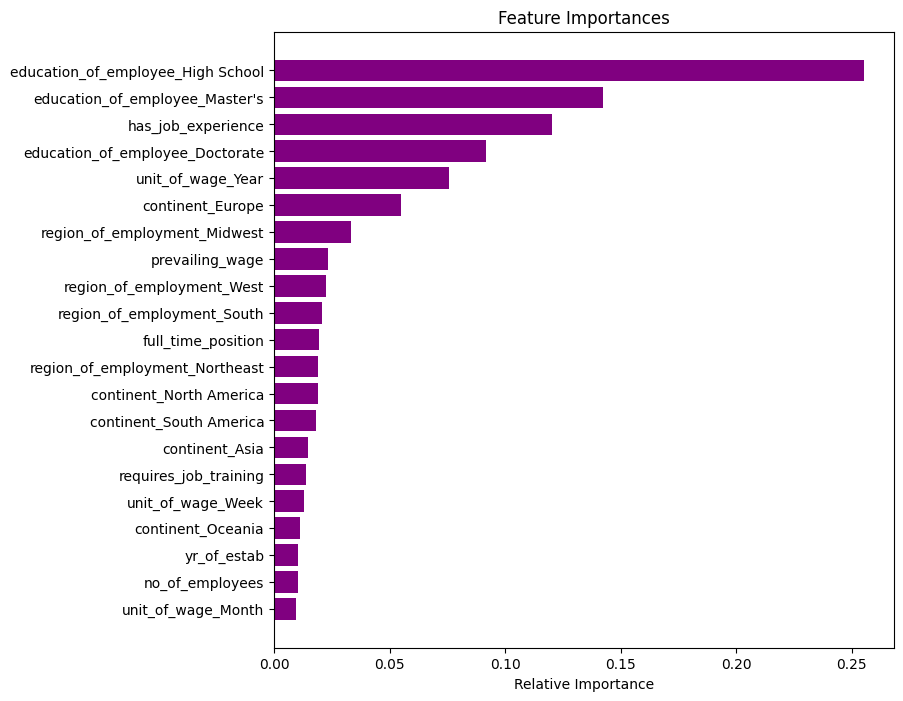

In [162]:
# importance of features in the tree building

importances = xgb_tuned.feature_importances_
indices = np.argsort(importances)

feature_names = list(X_train.columns)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="purple", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

**Observations:**


1. Education Levels as primary predictors:
    - The employee's education dominates the model's decisions, with education_of_employee_High School holding the highest importance (approx. 0.25), followed by Master's (\~0.15) and Doctorate (\~0.10)
    - This suggests lower education (High School) is a strong negative signal for visa approval, while advanced degrees positively influence predictions, consistent with EDA showing higher certification rates for Doctorate (87%) and Master's (79%).
2. Job Experience's Significant Role:
    - has_job_experience ranks third (\~0.12), highlighting its key contribution to the model's splits
    - Experienced applicants likely boost approval chances, reinforcing the business value of prioritizing profiles with prior work history to facilitate faster certifications.
3. Wage Structure and Value Influence:
    - unit_of_wage_Year (\~0.08) and prevailing_wage (\~0.03-0.04) feature prominently in the mid-range, possibly ensuring compliance with US standards
    - Less common units like Week (\~0.02) and Month (\~0.01) have lower impact, aligning with insights that non-yearly wages correlate with denials.

4. Regional and Continental Variations:
    - Geographic features show moderate importance, led by continent_Europe (\~0.07) and region_of_employment_Midwest (\~0.05), with others like West (\~0.04), South (\~0.04), and Northeast (\~0.035) following
    - This implies the model favors certain locations (Ex: Europe/Mid west), potentially due to workforce demand patterns, while rare continents like Oceania (/~0.02) contribute minimally.

5. Employer Factors:
    - Features related to the employer, such as yr_of_estab (\~0.015) and no_of_employees (\~0.01), rank at the bottom, suggesting company age and size play a minor role in predictions.

## Actionable Insights & Recommendations

### Comprehensive Observations and Insights - All Models



*   **Algorithm Class Performance:**
    *   **Boosting Models (XGBoost, Gradient Boosting, AdaBoost):** Consistently outperformed simple Tree and Bagging models. They demonstrated superior ability to handle the non-linear relationships and class imbalance within the visa dataset, yielding the highest F1-scores (~0.82).
    *   **Tree-Based Ensembles (Random Forest, Bagging):** While robust, they tended to overfit significantly on default parameters (achieving ~99% training accuracy but dropping to ~72-80% in validation). They generally prioritized Recall over Precision more aggressively than boosting models.
*   **Metric Trade-offs (Precision vs. Recall):**
    *   **Random Forest:** Typically provided the highest Recall (up to 0.91), making it the most 'generous' model for certifications. However, this came at the cost of lower Precision, meaning a higher risk of certifying ineligible candidates.
    *   **XGBoost and Gradient Boosting:** Provided the most stable F1-balance. They maintained high enough recall to support talent acquisition while ensuring better precision to safeguard compliance standards.
*   **Impact of Data Resampling:**
    *   **Original Data:** Models trained on the original distribution (with class weighting) generally showed the best generalization and stability.
    *   **Oversampling (SMOTE):** Yielded similar results to the original data for boosting models but introduced slight noise for others. It did not provide a breakthrough improvement over simple class weighting.
    *   **Undersampling:** Resulted in the poorest performance across all metrics. By discarding the majority of 'Certified' cases, the models lost critical information, leading to much lower F1-scores (~0.68 - 0.76).
*   **Suitability for the Problem:**
    *   The visa certification process involves complex interactions between education, wage, and region. Boosting algorithms are highly suitable as they iteratively correct errors, making them ideal for the 'noisy' and skewed real-world data provided by the OFLC.

#### Summary of Model Results

*   **Top Performer:** The tuned XGBoost model emerged as the most effective solution, achieving a high **F1-score of 0.824** on the test set. This demonstrates its superior ability to generalize to new, unseen visa applications compared to other ensemble and boosting methods.
*   **Strategic Metric Trade-off:**
    * We prioritized F1 score (0.824) to ensure there's a balance of compliance/legal risk and talent loss
    * Maintaining a stable Recall (0.88) ensures that the majority of eligible workers are identified for certification, thereby minimizing talent loss for U.S. employers.
    *   By maintaining a stable Precision (0.77), the model effectively manages compliance risks, ensuring that the OFLC does not certify a significant number of ineligible applications.
*   **Problem Suitability:**
    *   **Imbalance Handling:**
        - The model successfully navigated the class imbalance without requiring synthetic data generation, keeping predictions aligned with real-world distribution.
    *   **Efficiency:**
        - Given the nearly 1.7 million positions processed annually, XGBoost's speed and scalability make it the most viable tool for streamlining high-volume manual reviews.
    *   **Robustness:**
        - The minimal gap between validation and test scores confirms that the model is reliable.

### Actionable Insights



Based on the model analysis, the following factors significantly impact visa approval:

1. Education Level Matters Most:

    - The most positively influential feature in the model is education_level_Master.

    - Applicants with a Master's degree have significantly higher chances of approval compared to those with high school or lower degrees.


2. Job Training and Experience:

    - requires_job_training_No is a top predictor
    - Candidates who are immediately qualified for their roles are favoured without needing additional employer-sponsored training

3. Wage Structure:

    - unit_of_wage_Year and prevailing_wage are strong indicators.
    - Compliance with U.S. wage standards is critical; non-yearly wage structures (weekly or monthly) correlate with higher denial rates.

4. Regional Variations:

    - The model shows higher approval trends for certain regions, specifically the Midwest and for applicants coming from Europe.

### Business Recommendations



The following strategic recommendations can be derived from the project results:

1. Strategic Sourcing:
    - The business should prioritize candidates with higher education levels (Master's and Ph.D. holders) as they have a statistically higher probability of visa certification.
    - Flag applications with High School education or non-yearly wage structures for additional scrutiny.

2. Candidate Readiness:
    - Focus recruitment on "ready-to-work" candidates who do not require extensive on-the-job training, as these profiles align with successful certification patterns.

3. Regional Markets:
    - When expanding or sourcing for roles with high visa dependency, consider focusing efforts on the high-probability geographic regions based on higher approval trends for the Midwest region and for applicants originating from Europe.

4. Compliance Optimization:
    - Ensure that wage offers are structured as annual salaries rather than hourly or weekly rates to align with the characteristics of successful applications.

5. Operational Efficiency:
    - Use the XGBoost model as a decision-support tool to flag "high-risk" applications early, allowing the legal and HR teams to dedicate more resources to complex cases or reconsider candidates with low approval probabilities.

### Conclusion

- This project successfully developed a machine learning-based solution to assist the Office of Foreign Labor Certification (OFLC) in streamlining the visa approval process for EasyVisa.

- By analyzing historical visa application data, we built and evaluated multiple classification models to predict whether a visa application would be Certified or Denied.

- After extensive experimentation with original, oversampled, and undersampled data, hyperparameter tuning, and rigorous evaluation, XGBoost (tuned on original data) emerged as the final model.

- It delivered the best overall performance with an F1-score of 0.824, Recall of 0.882, Precision of 0.773 on the test set.

- The model demonstrated strong generalization and an excellent balance between identifying deserving candidates (high recall) and maintaining precision.

- Education and Experience are the strongest drivers of visa approval. Applicants with Master's or Doctorate degrees and prior job experience have significantly higher chances of certification.

- Deploy the XGBoost model as a pre-screening tool to automatically shortlist high-probability applications, potentially reducing manual review effort by 30-40%.

- Prioritize profiles with advanced education, relevant job experience, and favorable employment regions for faster processing.

- Flag applications with High School education or non-yearly wage structures for additional scrutiny.
Periodically retrain the model with new data to keep it updated with evolving immigration trends.

- This data-driven approach not only accelerates the visa approval process but also helps US employers attract qualified global talent more efficiently while maintaining regulatory compliance.